# Description

This is an example of using the [Deepsensor package](https://alan-turing-institute.github.io/deepsensor/index.html) to infer surface NO2 concentrations with multiple input data sources.

[Installation instructions for the Deepsensor package and dependencies.](https://alan-turing-institute.github.io/deepsensor/getting-started/installation.html)

## Setup

A conda environment `deepsensor_cenv` was set up for the deepsensor package and its dependencies (`/discover/nobackup/cmalings/venvs/deepsensor_env`).

This was made available as a Kernel in JupyterHub: `Python [conda env:.conda-deepsensor_cenv]`

In [1]:
# Basic packages:
import os
import logging
import time
import json
logging.captureWarnings(True)

# Data management & manipulation packages:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as sps

# Plotting packages:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Deepsensor:
import deepsensor.torch
from deepsensor.data import DataProcessor
from deepsensor.data import TaskLoader
from deepsensor.data import construct_circ_time_ds
from deepsensor.model import ConvNP
from deepsensor.train import Trainer, set_gpu_default_device
# GPU Setup:
try:
    set_gpu_default_device()
except:
    pass

# input data
s_data_folder = "/discover/nobackup/cmalings/input/ASIA-AQ Experimentation"
s_data_folder_GCAS = "/discover/nobackup/cmalings/input/ASIA-AQ GCAS Simulation"

# basic settings
# s_name_for_model = 'test_4' # initial full testing
# s_name_for_model = 'test_5' # GPU Testing, time and lulc as target aux. info
s_name_for_model = 'test_6' # CPU Testing, testing additional automation options
Consider_ground_monitors_as_input = True
Fraction_of_ground_monitors_to_train_on = 0.8
Use_GEOSCF = True
Use_TROPOMI = True
Use_GEMS = True
Use_GCAS = True
Use_LULC = False

# Crossvalidation Options
### Spatial CV: "randomly" split sites (according to site latitude) and uses all but one split for training, testing on the last split. If False, data from all sites are used for both training and testing.
Spatial_CV = True
n_fold_spatial_cv = 5
i_fold_spatial_cv = 0

### Temporal CV: Hold out every [n_fold_temporal_cv]th timestamp for testing, use the rest for training
Temporal_CV = False
n_fold_temporal_cv = 7
i_fold_temporal_cv = 0

### Split the data by month to define training and testing sets
Temporal_Month_Split = True
Train_in_March = True

# working data folder and file
processor_dir = f"/discover/nobackup/cmalings/output/ASIA-AQ/deepsensor_working_data/{s_name_for_model}/"
data_fpath = os.path.join(processor_dir,"tmp.nc")
try:
    os.mkdir(processor_dir)
except:
    pass

b_Retrain_Model = True
b_Repeat_Evaluation = True

# For recording purposes, write settings out to a JSON file
d_settings = {'Model Name':s_name_for_model,
              'Ground Monitors Considered for Input':Consider_ground_monitors_as_input,
              'Ground Monitor Training Fraction':Fraction_of_ground_monitors_to_train_on,
              'Use GEOS-CF':Use_GEOSCF,
              'Use TROPOMI':Use_TROPOMI,
              'Use GEMS':Use_GEMS,
              'Use GCAS':Use_GCAS,
              'Use LULC':Use_LULC,
              'Spatial Cross-Validation':Spatial_CV,
              'Number of Spatial Cross-Validation Folds':n_fold_spatial_cv,
              'Spatial Cross-Validation Fold':i_fold_spatial_cv,
              'Temporal Cross-Validation':Temporal_CV,
              'Number of Temporal Cross-Validation Folds':n_fold_temporal_cv,
              'Temporal Cross-Validation Fold':i_fold_temporal_cv,
              'Temporal Split By Month':Temporal_Month_Split,
              'Training in March':Train_in_March,
             }
with open(os.path.join(processor_dir,s_name_for_model+'_settings.json'), 'w') as o_file:
    json.dump(d_settings, o_file, indent=4)


__*Note*__: to enable plotting of new regions, the region must be defined for the deepsensor plotting function.

File to modify: `/discover/nobackup/cmalings/.conda/envs/deepsensor_cenv/lib/python3.13/site-packages/deepsensor/plot.py`

Function to modufy: `extent_str_to_tuple` (line 1068)

Modification to make: add to the list
```
elif extent == 'new_region':
    return (min_lon,max_lon,min_lat,max_lat)
```

__*Also Note*__: Plotting is currently not working on NCCS Jupyterhub since this doesn't have the internet access needed to download the shapefiles. A temporary workaround is included for showing results.

## Load Data

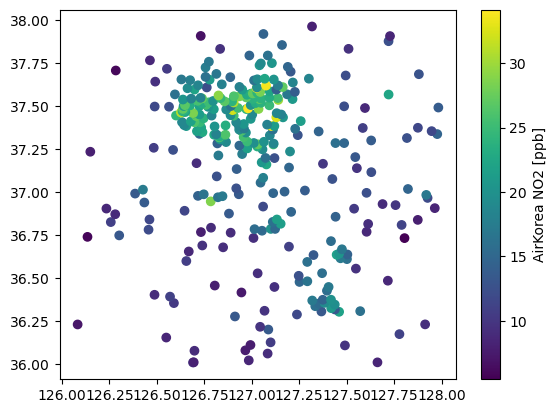

In [2]:
# Load AirKorea Data
f_data_airkorea_raw = pd.read_csv(os.path.join(s_data_folder,'AirKorea_AsiaAQ_Seoul_station_h.csv'))

# Ensure DateTime Formatting:
f_data_airkorea_raw['time'] = pd.to_datetime(f_data_airkorea_raw['time'])

# Only retain data to be used here, and set the index to the proper sequence (time, lat, lon):
f_data_airkorea = f_data_airkorea_raw[['lat','lon','time','NO2']].set_index(['time','lat','lon'])

# Check Data
f_data_airkorea_avg = f_data_airkorea.groupby(['lat','lon']).mean('time').reset_index()
plt.scatter(f_data_airkorea_avg['lon'],f_data_airkorea_avg['lat'],c=f_data_airkorea_avg['NO2'])
plt.colorbar(label='AirKorea NO2 [ppb]')
plt.show()

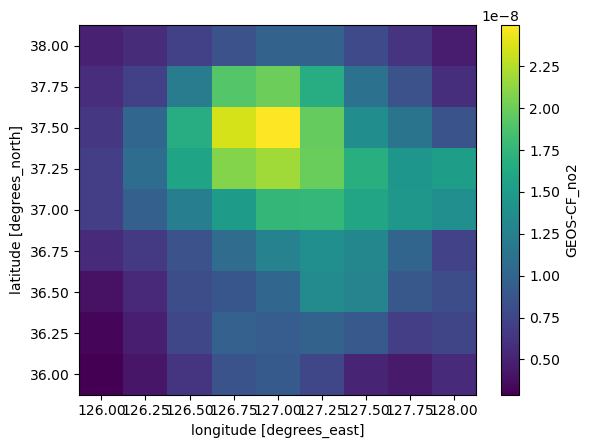

In [3]:
# Load GOES-CF Data
if Use_GEOSCF:
    a_data_GEOSCF_raw = xr.open_dataset(os.path.join(s_data_folder,'GEOS-CF_AsiaAQ_Seoul_Grid_025_h.nc'))
    
    # Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
    a_data_GEOSCF = a_data_GEOSCF_raw[['no2',
                                       'tropcol_no2',
                                       'totcol_no2',
                                       'u2m',
                                       'v2m',
                                       'wndspd_2m',
                                       't2m',
                                       'q2m',
                                       'rh',
                                       'cldtt',
                                       'tprec',
                                       'troppb',
                                       'zl',
                                       'zpbl',
                                      ]].transpose('time','lat','lon')
    
    # Append data source to variable names:
    a_data_GEOSCF = a_data_GEOSCF.rename({s_var:'GEOS-CF_'+s_var for s_var in a_data_GEOSCF})
    
    # Check Data
    a_data_GEOSCF['GEOS-CF_no2'].mean('time').plot()

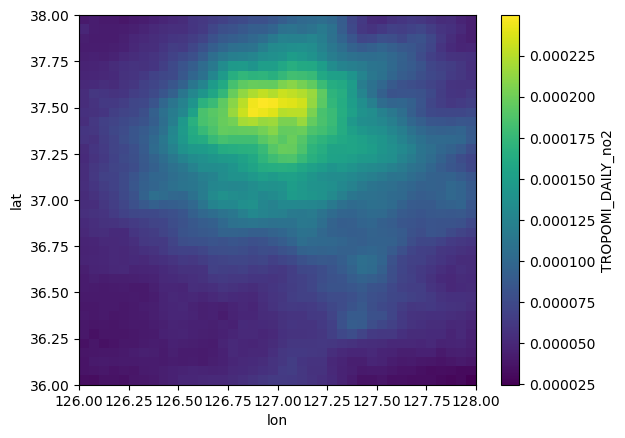

In [4]:
# Load TROPOMI Data
if Use_TROPOMI:
    a_data_TROPOMI_raw = xr.open_dataset(os.path.join(s_data_folder,'TROPOMI_AsiaAQ_Seoul_Regrid_005_h.nc'))
    
    # Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
    a_data_TROPOMI = a_data_TROPOMI_raw[['no2','o3']].transpose('time','lat','lon')
    
    # Append data source to variable names:
    a_data_TROPOMI = a_data_TROPOMI.rename({s_var:'TROPOMI_'+s_var for s_var in a_data_TROPOMI})
    
    # Create Daily-aggregate TROPOMI Data:
    # Define "days" centered at nominal overpass time:
    v_days = np.arange(np.datetime64('2024-02-01T04:30:00'),np.datetime64('2024-03-31T23:59:59'),np.timedelta64(1,'D'))
    # Match each overpass with the nearest nominal day:
    v_day_assignments = [v_days[np.argmin(abs(v_days - t_time))] for t_time in a_data_TROPOMI.time.values]
    # Use coordinate grouping and averaging to create daily averages:
    a_data_TROPOMI_daily = a_data_TROPOMI.assign_coords({'date':('time',v_day_assignments)}).groupby('date').mean('time')
    # Rename variables and dimensions:
    a_data_TROPOMI_daily = a_data_TROPOMI_daily.rename({'date':'time'})
    a_data_TROPOMI_daily = a_data_TROPOMI_daily.rename({s_var:s_var.replace('TROPOMI_','TROPOMI_DAILY_') for s_var in a_data_TROPOMI})
    
    # Check Data:
    a_data_TROPOMI_daily['TROPOMI_DAILY_no2'].mean('time').plot()

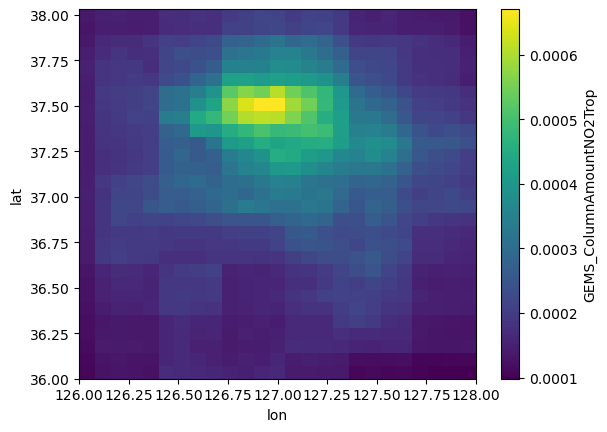

In [5]:
# Load GEMS
if Use_GEMS:
    a_data_GEMS_raw = xr.open_dataset(os.path.join(s_data_folder,'GEMS_AsiaAQ_Seoul_Regrid_008_h.nc'))
    
    # Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
    a_data_GEMS = a_data_GEMS_raw[['ColumnAmountNO2Trop','ColumnAmountNO2']].transpose('time','lat','lon')
    
    # Append data source to variable names:
    a_data_GEMS = a_data_GEMS.rename({s_var:'GEMS_'+s_var for s_var in a_data_GEMS})
    
    # Check Data
    a_data_GEMS['GEMS_ColumnAmountNO2Trop'].mean('time').plot()

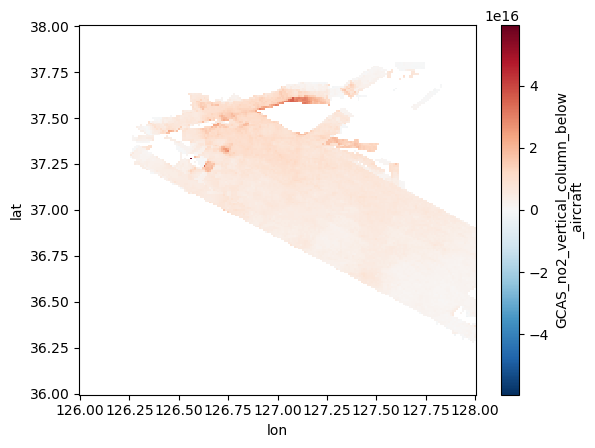

In [6]:
# Load GCAS Data
if Use_GCAS:
    # Days with GCAS overflight:
    l_days_GCAS = [
                  '20240217',
                  '20240223',
                  '20240226',
                  '20240301',
                  '20240302',
                  '20240303',
                  '20240307',
                  '20240309'
                  ]
    
    # GCAS data variables to be used:
    l_GCAS_vars_to_keep = ['no2_vertical_column_below_aircraft','model_no2_vertical_column_below_aircraft']
    
    # Load and concatenate by time, and set the dimensions to the proper sequence (time, lat, lon):
    l_data_GCAS = [xr.open_dataset(os.path.join(s_data_folder_GCAS,f'GCAS_NO2_{s_day}_Seoul_Gridded_001_hourly.nc'))[l_GCAS_vars_to_keep] for s_day in l_days_GCAS]
    a_data_GCAS = xr.concat(l_data_GCAS,'time').transpose('time','lat','lon')
    
    # Append data source to variable names:
    a_data_GCAS = a_data_GCAS.rename({s_var:'GCAS_'+s_var for s_var in a_data_GCAS})
    
    # Check Data
    a_data_GCAS['GCAS_no2_vertical_column_below_aircraft'].mean('time').plot()

In [7]:
# Load Land Use Dataset
if Use_LULC:
    a_data_LULC = xr.open_dataset(os.path.join(s_data_folder,'MCD12Q1.061_500m_aid0001.nc'))
    a_data_LULC = a_data_LULC[['LC_Type1']].mean('time').rename({'LC_Type1':'MCD12Q1_LC_Type1'}).sel(lat=slice(38,36),lon=slice(126,128))
    
    # Covert to categorical classes - THIS MAKES THE FILE TOO BIG
    if False:
        for i_class in np.unique(a_data_LULC['MCD12Q1_LC_Type1'].values):
            a_data_LULC['MCD12Q1_LC_Type1_Class'+str(int(i_class))] = xr.zeros_like(a_data_LULC['MCD12Q1_LC_Type1'])
            a_data_LULC['MCD12Q1_LC_Type1_Class'+str(int(i_class))] = a_data_LULC['MCD12Q1_LC_Type1_Class'+str(int(i_class))].where(a_data_LULC['MCD12Q1_LC_Type1'] != i_class,1)

    # Check Data
    a_data_LULC['MCD12Q1_LC_Type1'].plot()
    # a_data_LULC['MCD12Q1_LC_Type1_Class13'].plot()

### Align all data to common times

The Deepsensor package uses `time` as its indexing dimension; essentially, `time` is used to match up information across the different context and target datasets, to identify which data should be grouped together as representing the "same thing". For time-series applications, you can specify lags so that data from adjacent times can be considerred as inputs; however, **Deepsensor assumes that `time` is evenly spaced**; if this is not the case, it will cause issues. Here, we are just using the time as an indexing, so we will ignore that requirement. 

To ensure things will work properly, we need to align all of our inputs to have a common time vector, filling in blanks where needed.

In [8]:
# Function to align times
def F_align_times(a_in,v_time,dt_tol = np.timedelta64(30,'m')):
    # Convert Data Frames to Xarray:
    if (type(a_in) == pd.DataFrame):
        b_frame = True
        a_in = a_in.to_xarray()
    else:
        b_frame = False
    # Use re-indexing with tolerance to get the nearest time in the sample:
    a_out = a_in.reindex(time=v_time,
                         method="nearest",
                         tolerance=dt_tol,
                         copy=False,
                         kwargs={'fill_value':'extrapolate'})
    # Convert back to dataframe if needed:
    if b_frame:
        a_out = a_out.to_dataframe().dropna(how='all')
    return a_out


# Target times: AirKorea Monitor Data
v_time = f_data_airkorea.reset_index()['time'].unique()

# Target times: GCAS Flights
# v_time = a_data_GCAS.time.values

f_data_airkorea_aligned = F_align_times(f_data_airkorea,v_time)
if Use_GEOSCF:
    a_data_GEOSCF_aligned = F_align_times(a_data_GEOSCF,v_time) # 7MB
if Use_TROPOMI:
    a_data_TROPOMI_daily_aligned = F_align_times(a_data_TROPOMI_daily,v_time,dt_tol = np.timedelta64(12,'h')) # 37MB
if Use_GEMS:
    a_data_GEMS_aligned = F_align_times(a_data_GEMS,v_time) # 17MB
if Use_GCAS:
    a_data_GCAS_aligned = F_align_times(a_data_GCAS,v_time) # 925MB !!!

if Use_LULC:
    # Add time dimension to land use land cover dataset; include hour-of-day information; 41GB !!!!!
    a_data_AUX_aligned = a_data_LULC.expand_dims({'time':v_time}).transpose('time','lat','lon')
    a_data_AUX_aligned['Time_of_Day'] = xr.DataArray(pd.to_datetime(v_time).hour,dims=('time'),coords={'time':v_time}).expand_dims({'lat':a_data_AUX_aligned.lat.values,'lon':a_data_AUX_aligned.lon.values}).transpose('time','lat','lon')
else:
    a_data_AUX_aligned = xr.DataArray(pd.to_datetime(v_time).hour,name='Time_of_Day',dims=('time'),coords={'time':v_time}).expand_dims({'lat':np.arange(36,38.5,0.5),'lon':np.arange(126,128.5,0.5)}).transpose('time','lat','lon')

# Verify alignment
b_aligned = True
if len(v_time) != len(f_data_airkorea_aligned.reset_index()['time'].unique()):
    b_aligned = False
    print('Warning: AirKorea data are not temporally aligned.')
if Use_GEOSCF:
    if len(v_time) != len(a_data_GEOSCF_aligned.time.values):
        b_aligned = False
        print('Warning: GEOS-CF data are not temporally aligned.')
if Use_TROPOMI:        
    if len(v_time) != len(a_data_TROPOMI_daily_aligned.time.values):
        b_aligned = False
        print('Warning: TROPOMI data are not temporally aligned.')
if Use_GEMS:        
    if len(v_time) != len(a_data_GEMS_aligned.time.values):
        b_aligned = False
        print('Warning: GEMS data are not temporally aligned.')
if Use_GCAS:        
    if len(v_time) != len(a_data_GCAS_aligned.time.values):
        b_aligned = False
        print('Warning: GCAS data are not temporally aligned.')
if b_aligned:
    print('All data are aligned.')


All data are aligned.


### Define Training and Testing Datasets

The full aligned datasets above are split accoridng to training and testing time periods. Furthermore, ground monitor data can be split according to site, such that only data from certain sites are used for training, while data from other sites are entirely held aside.

In [9]:
# Split Data by times:
if Temporal_CV:
    id_test = range(i_fold_temporal_cv,len(v_time),n_fold_temporal_cv)
    v_time_test = v_time[id_test]
    v_time_train = v_time[[index for index in range(0,len(v_time)) if index not in id_test]]
elif Temporal_Month_Split:
    if Train_in_March:
        v_time_train = v_time[v_time >= np.datetime64('2024-03-01T00:00:00')]
        v_time_test = v_time[v_time < np.datetime64('2024-03-01T00:00:00')]
    else:
        v_time_train = v_time[v_time < np.datetime64('2024-03-01T00:00:00')]
        v_time_test = v_time[v_time >= np.datetime64('2024-03-01T00:00:00')]
else:
    v_time_test = v_time
    v_time_train = v_time

# Split Site Data Spatially:
if Spatial_CV:
    # Assign site IDs to AirKorea data locations:
    f_data_airkorea_aligned_with_siteid = f_data_airkorea_aligned
    f_data_airkorea_aligned_with_siteid['siteID'] = f_data_airkorea_aligned_with_siteid.groupby(['lat', 'lon']).ngroup()
    # Divide by site IDs:
    v_test_siteID = range(i_fold_spatial_cv,max(f_data_airkorea_aligned_with_siteid['siteID'])+1,n_fold_spatial_cv)
    f_data_airkorea_aligned_test_sites = f_data_airkorea_aligned_with_siteid[f_data_airkorea_aligned_with_siteid['siteID'].isin(v_test_siteID)][['NO2']]
    f_data_airkorea_aligned_train_sites = f_data_airkorea_aligned_with_siteid[~(f_data_airkorea_aligned_with_siteid['siteID'].isin(v_test_siteID))][['NO2']]
else:
    f_data_airkorea_aligned_test_sites = f_data_airkorea_aligned
    f_data_airkorea_aligned_train_sites = f_data_airkorea_aligned

# Define Training and Testing Datasets:
v_datatypes = ['airkorea']
d_training = {'airkorea':F_align_times(f_data_airkorea_aligned_train_sites,v_time_train)}
d_testing = {'airkorea':F_align_times(f_data_airkorea_aligned_test_sites,v_time_test)}

if Consider_ground_monitors_as_input:
    # If ground monitors are to be used as inputs as well: 
    d_testing['airkorea_input'] = F_align_times(f_data_airkorea_aligned_train_sites,v_time_test)
    v_datatypes += ['airkorea_input']
if Use_GEOSCF:
    d_training['GEOSCF'] = F_align_times(a_data_GEOSCF_aligned,v_time_train)
    d_testing['GEOSCF'] = F_align_times(a_data_GEOSCF_aligned,v_time_test)
    v_datatypes += ['GEOSCF']
if Use_TROPOMI:
    d_training['TROPOMI'] = F_align_times(a_data_TROPOMI_daily_aligned,v_time_train)
    d_testing['TROPOMI'] = F_align_times(a_data_TROPOMI_daily_aligned,v_time_test)
    v_datatypes += ['TROPOMI']
if Use_GEMS:
    d_training['GEMS'] = F_align_times(a_data_GEMS_aligned,v_time_train)
    d_testing['GEMS'] = F_align_times(a_data_GEMS_aligned,v_time_test)
    v_datatypes += ['GEMS']
if Use_GCAS:
    d_training['GCAS'] = F_align_times(a_data_GCAS_aligned,v_time_train)
    d_testing['GCAS'] = F_align_times(a_data_GCAS_aligned,v_time_test)
    v_datatypes += ['GCAS']

print('Data Split Summary:')
print(f'  AirKorea: {len(d_training['airkorea'])} training samples from {len(d_training['airkorea'].groupby(['lat','lon']).mean())} sites; {len(d_testing['airkorea'])} testing samples from {len(d_testing['airkorea'].groupby(['lat','lon']).mean())} sites')
if Use_GEOSCF:
    print(f'  GEOS-CF:  {len(d_training['GEOSCF'].time)} training hours; {len(d_testing['GEOSCF'].time)} testing hours')
if Use_TROPOMI:
    print(f'  TROPOMI:  {str((~np.isnan(d_training['TROPOMI']['TROPOMI_DAILY_no2'].groupby('time.day').mean())).any(dim=['lat','lon']).sum().values)} days with training data; {str((~np.isnan(d_testing['TROPOMI']['TROPOMI_DAILY_no2'].groupby('time.day').mean())).any(dim=['lat','lon']).sum().values)} days with testing data')
if Use_GEMS:
    print(f'  GEMS:     {str((~np.isnan(d_training['GEMS']['GEMS_ColumnAmountNO2Trop'])).any(dim=['lat','lon']).sum().values)} hours with training data; {str((~np.isnan(d_testing['GEMS']['GEMS_ColumnAmountNO2Trop'])).any(dim=['lat','lon']).sum().values)} hours with testing data')
if Use_GCAS:
    print(f'  GCAS:     {str((~np.isnan(d_training['GCAS']['GCAS_no2_vertical_column_below_aircraft'])).any(dim=['lat','lon']).sum().values)} hours with training data; {str((~np.isnan(d_testing['GCAS']['GCAS_no2_vertical_column_below_aircraft'])).any(dim=['lat','lon']).sum().values)} hours with testing data')


Data Split Summary:
  AirKorea: 178463 training samples from 249 sites; 42829 testing samples from 63 sites
  GEOS-CF:  735 training hours; 696 testing hours
  TROPOMI:  31 days with training data; 28 days with testing data
  GEMS:     185 hours with training data; 133 hours with testing data
  GCAS:     33 hours with training data; 19 hours with testing data


### Process Data

A data processor preconditions data, assigning common names for the dimensions and normalizing data. See the [Deepsensor DataProcessor description](https://alan-turing-institute.github.io/deepsensor/user-guide/data_processor.html) for details.

The data processor is created initially by informing it about the names of the two spatial dimensions of that data. *Currently, Deepsensor assumes all data are organized according to two spatial and one temporal dimension.* Each dataset is then fed into the processor, and a method for normalization is assigned for its varaibles (`positive_semidefinite`, `mean_std`, and `min_max` would be common options). The data processor remembers how to normalize and un-normalize the data; if new data is fed into the processor with the same varaible name, it will normalize the new data in the same way.

Here, the processors are calibrated considering the training data only.

In [10]:
# Define Data Processor
data_processor = DataProcessor(x1_name="lat", x2_name="lon")

# Condition the processor on the training data:
_ = data_processor(d_training['airkorea'], method='positive_semidefinite')
if Use_GEOSCF:
    _ = data_processor(d_training['GEOSCF'], method='mean_std')
if Use_TROPOMI:
    _ = data_processor(d_training['TROPOMI'], method='positive_semidefinite')
if Use_GEMS:
    _ = data_processor(d_training['GEMS'], method='positive_semidefinite')
if Use_GCAS:
    _ = data_processor(d_training['GCAS'], method='positive_semidefinite')
_ = data_processor(a_data_AUX_aligned,method='min_max')

print(data_processor)

# Process Training and Testing Data:
d_training_processed = {}
d_testing_processed = {}
for s_datatype in v_datatypes:
    try:
        d_training_processed[s_datatype] = data_processor(d_training[s_datatype])
    except:
        pass
    d_testing_processed[s_datatype] = data_processor(d_testing[s_datatype])
a_data_AUX_processed = data_processor(a_data_AUX_aligned,method='min_max')

data_processor.save(processor_dir)

DataProcessor with normalisation params:
{'GCAS_model_no2_vertical_column_below_aircraft': {'method': 'positive_semidefinite',
                                                   'params': {'min': 1903927729586176.2,
                                                              'std': 4719630766337003.0}},
 'GCAS_no2_vertical_column_below_aircraft': {'method': 'positive_semidefinite',
                                             'params': {'min': -3067127965738595.5,
                                                        'std': 4162470313991670.5}},
 'GEMS_ColumnAmountNO2': {'method': 'positive_semidefinite',
                          'params': {'min': 9.465814946452156e-05,
                                     'std': 0.0001677026872967551}},
 'GEMS_ColumnAmountNO2Trop': {'method': 'positive_semidefinite',
                              'params': {'min': 6.853010563645512e-05,
                                         'std': 0.00013979430200689329}},
 'GEOS-CF_cldtt': {'method': 'mean_st

## Model Training

### Define a Task Loader

A 'Task' for Deepsensor is a combination of a 'context' (the information input into the model) and a 'target' (what the model is supposed to be outputting). Read more about the [Deepsensor Task here](https://alan-turing-institute.github.io/deepsensor/user-guide/task.html). A Task Loader is a tool which tells the package how to assemble a task. Deepsensor uses times for indexing samples, so here, the Task Loader will take a timestamp as input, and output a Task, i.e., the context and target data associated to that time. Read more about the [Deepsensor TaskLoader here](https://alan-turing-institute.github.io/deepsensor/user-guide/task_loader.html).

Here we will define two task loaders, one for the training data and one for the testing data. If we were purely splitting our dataset by time, we could define a single task loader and just feed it either times in the training or testing datasets. However, since we are using seperate target locations for training and testing, I am defining two loaders (maybe there is a cleaner way to do this which I am missing).

When calling a task loader, you need to specify the context and target samplings. There are a [few options for this](https://alan-turing-institute.github.io/deepsensor/user-guide/task_loader.html#taskloader-tour) based on what you are training a model to do. For example:
 - `context_sampling="all"`: The default; uses all the data.
 - `context_sampling="split"`: Splits a dataset between the context and target; useful if you want to interpolate to unseen locations.
 - `context_sampling=0.1`: Randomly sample a fraction (e.g., 10%) of the data; useful if you want to simulate sparsity.
 - `context_sampling=50`: Randomly sample a fixed number of points from the data; similar to above.
Additional options can combinations of options can be used to tailor the tasks to specific goals, like gap-filling or forecasting. You can also specify a list of samplings for the different contexts if you want to apply different strategies.


Here they are both "all", i.e., all the data is going to be used. There is a way to use other options to do more clever things, however; for example, you can sample only a fraction of certain inputs to 

['split', 'all', 'all', 'all', 'all']
['all', 'all', 'all', 'all', 'all']
Training Task Loader Information:
TaskLoader(5 context sets, 1 target sets)
Context variable IDs: (('NO2',), ('GEOS-CF_no2', 'GEOS-CF_tropcol_no2', 'GEOS-CF_totcol_no2', 'GEOS-CF_u2m', 'GEOS-CF_v2m', 'GEOS-CF_wndspd_2m', 'GEOS-CF_t2m', 'GEOS-CF_q2m', 'GEOS-CF_rh', 'GEOS-CF_cldtt', 'GEOS-CF_tprec', 'GEOS-CF_troppb', 'GEOS-CF_zl', 'GEOS-CF_zpbl'), ('TROPOMI_DAILY_no2', 'TROPOMI_DAILY_o3'), ('GEMS_ColumnAmountNO2Trop', 'GEMS_ColumnAmountNO2'), ('GCAS_no2_vertical_column_below_aircraft', 'GCAS_model_no2_vertical_column_below_aircraft'))
Target variable IDs: (('NO2',),)
Auxiliary-at-target variable IDs: ('Time_of_Day',)


Example Testing Task Information:
time: 2024-02-17 01:30:00
ops: []
X_c: [(2, 244), ((1, 9), (1, 9)), ((1, 40), (1, 40)), ((1, 29), (1, 25)), ((1, 201), (1, 201))]
Y_c: [(1, 244), (14, 9, 9), (2, 40, 40), (2, 29, 25), (2, 201, 201)]
X_t: [(2, 62)]
Y_t: [(1, 62)]
Y_t_aux: (1, 62)





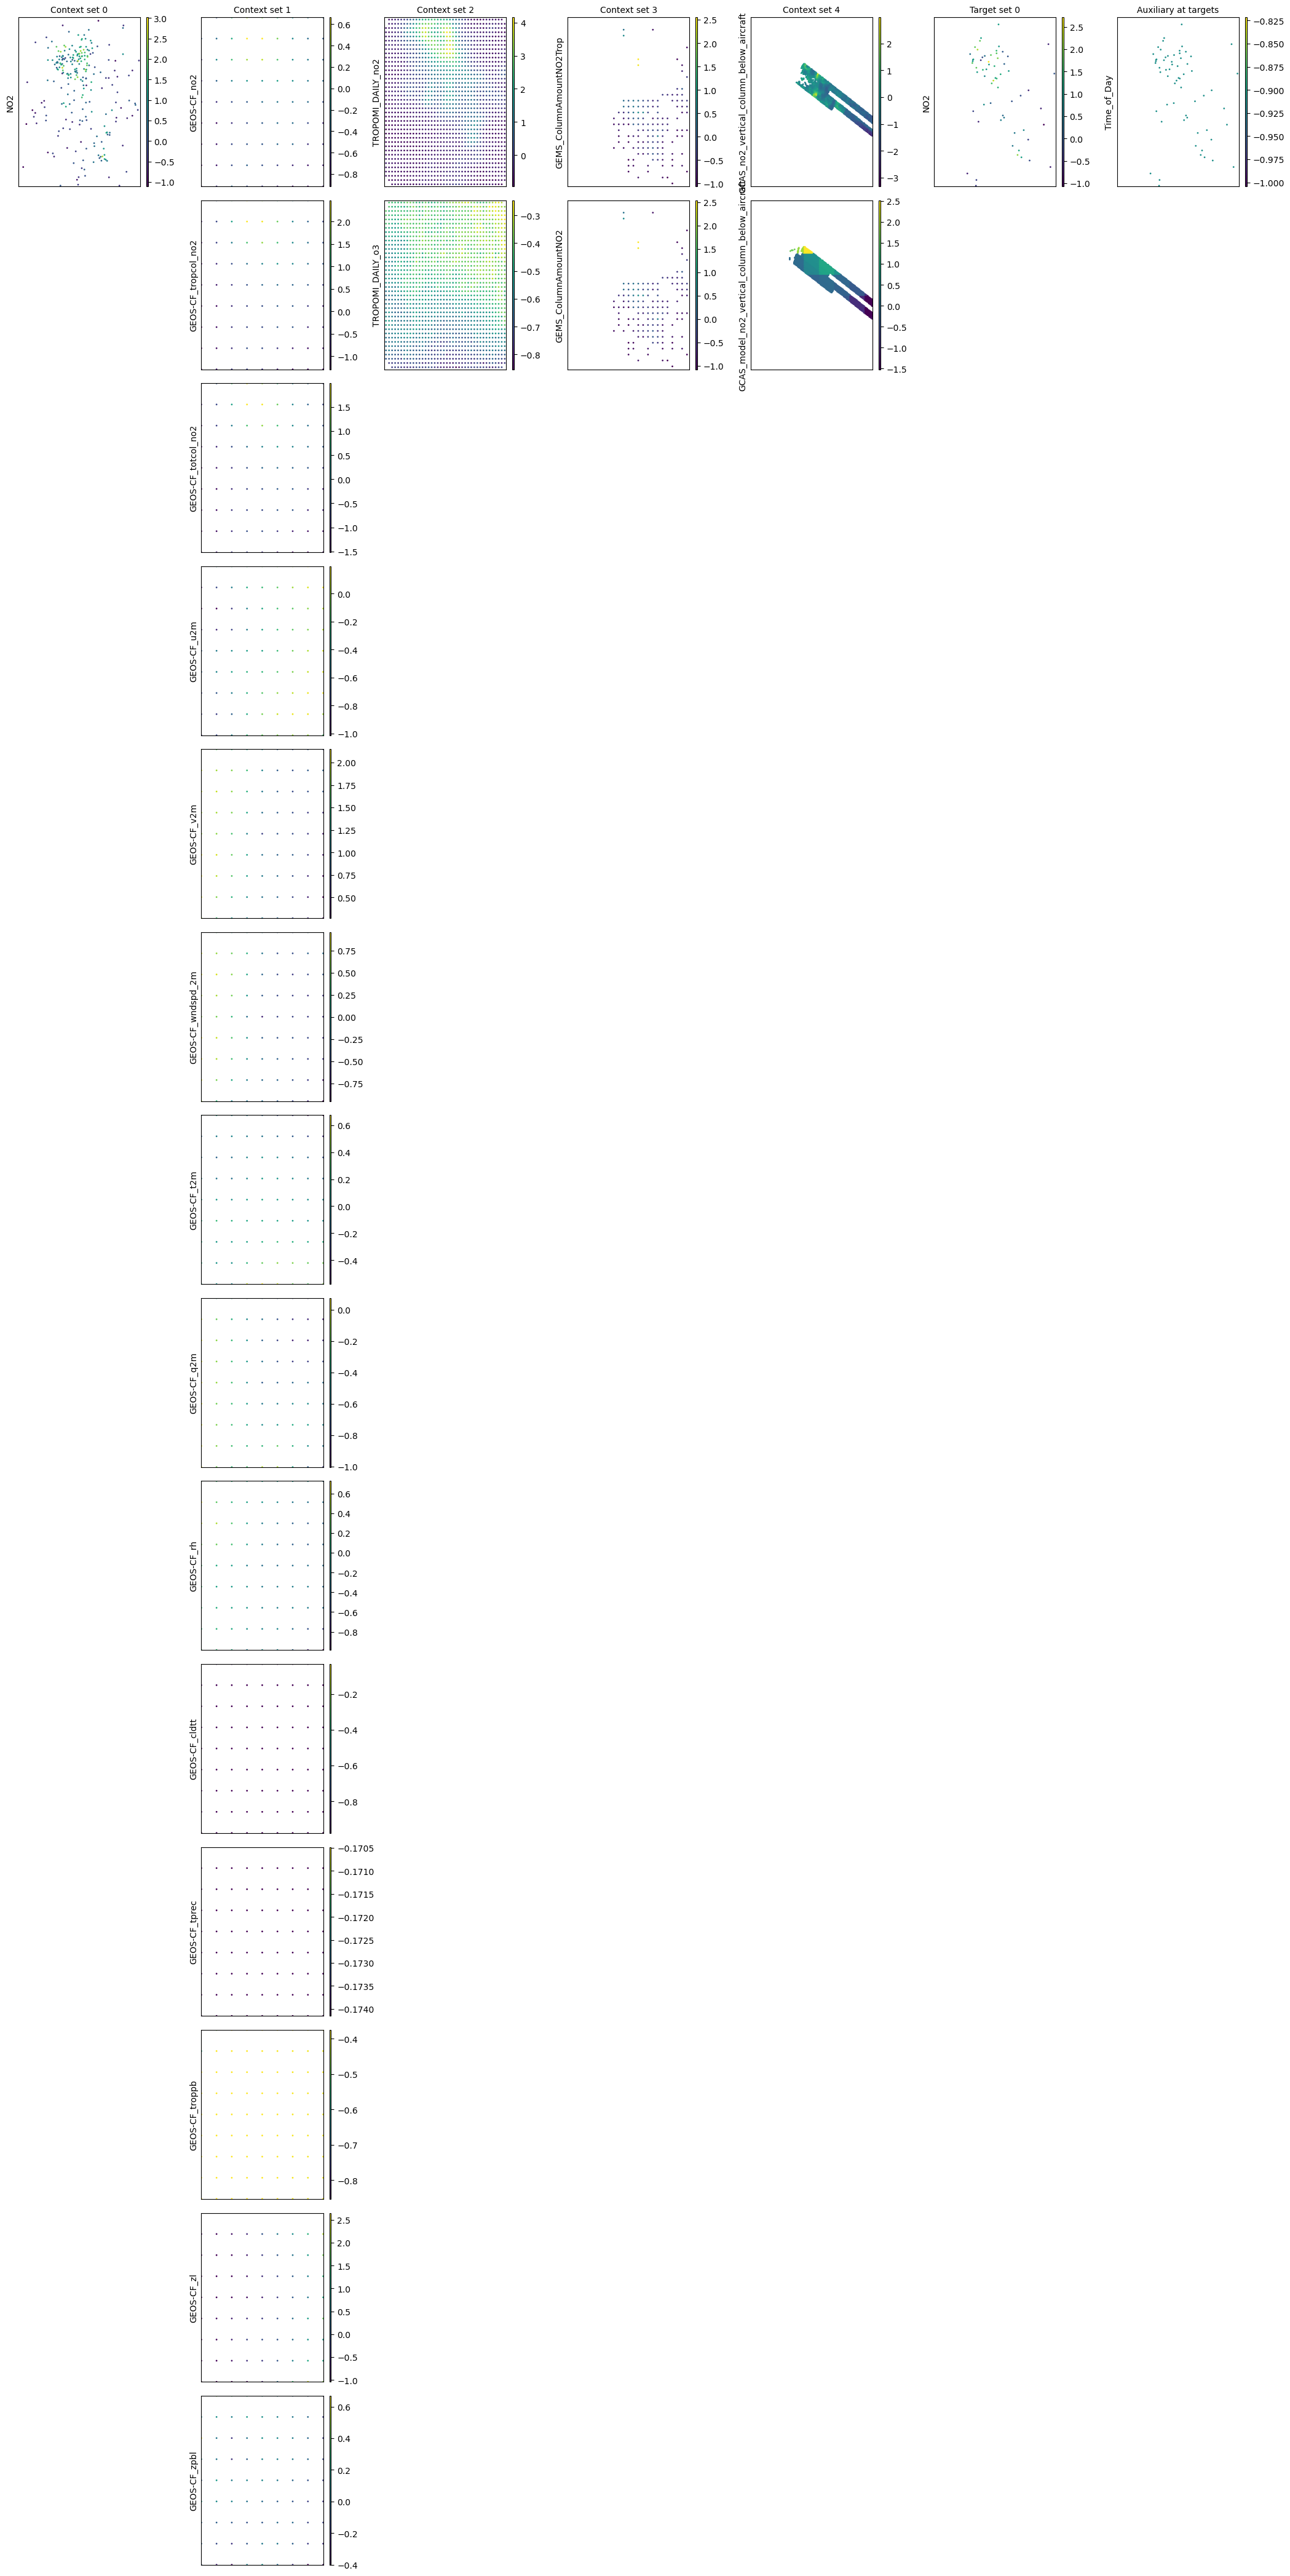

Example Training Task Information:
time: 2024-02-17 01:30:00
ops: []
X_c: [(2, 244), ((1, 9), (1, 9)), ((1, 40), (1, 40)), ((1, 29), (1, 25)), ((1, 201), (1, 201))]
Y_c: [(1, 244), (14, 9, 9), (2, 40, 40), (2, 29, 25), (2, 201, 201)]
X_t: [(2, 62)]
Y_t: [(1, 62)]
Y_t_aux: (1, 62)





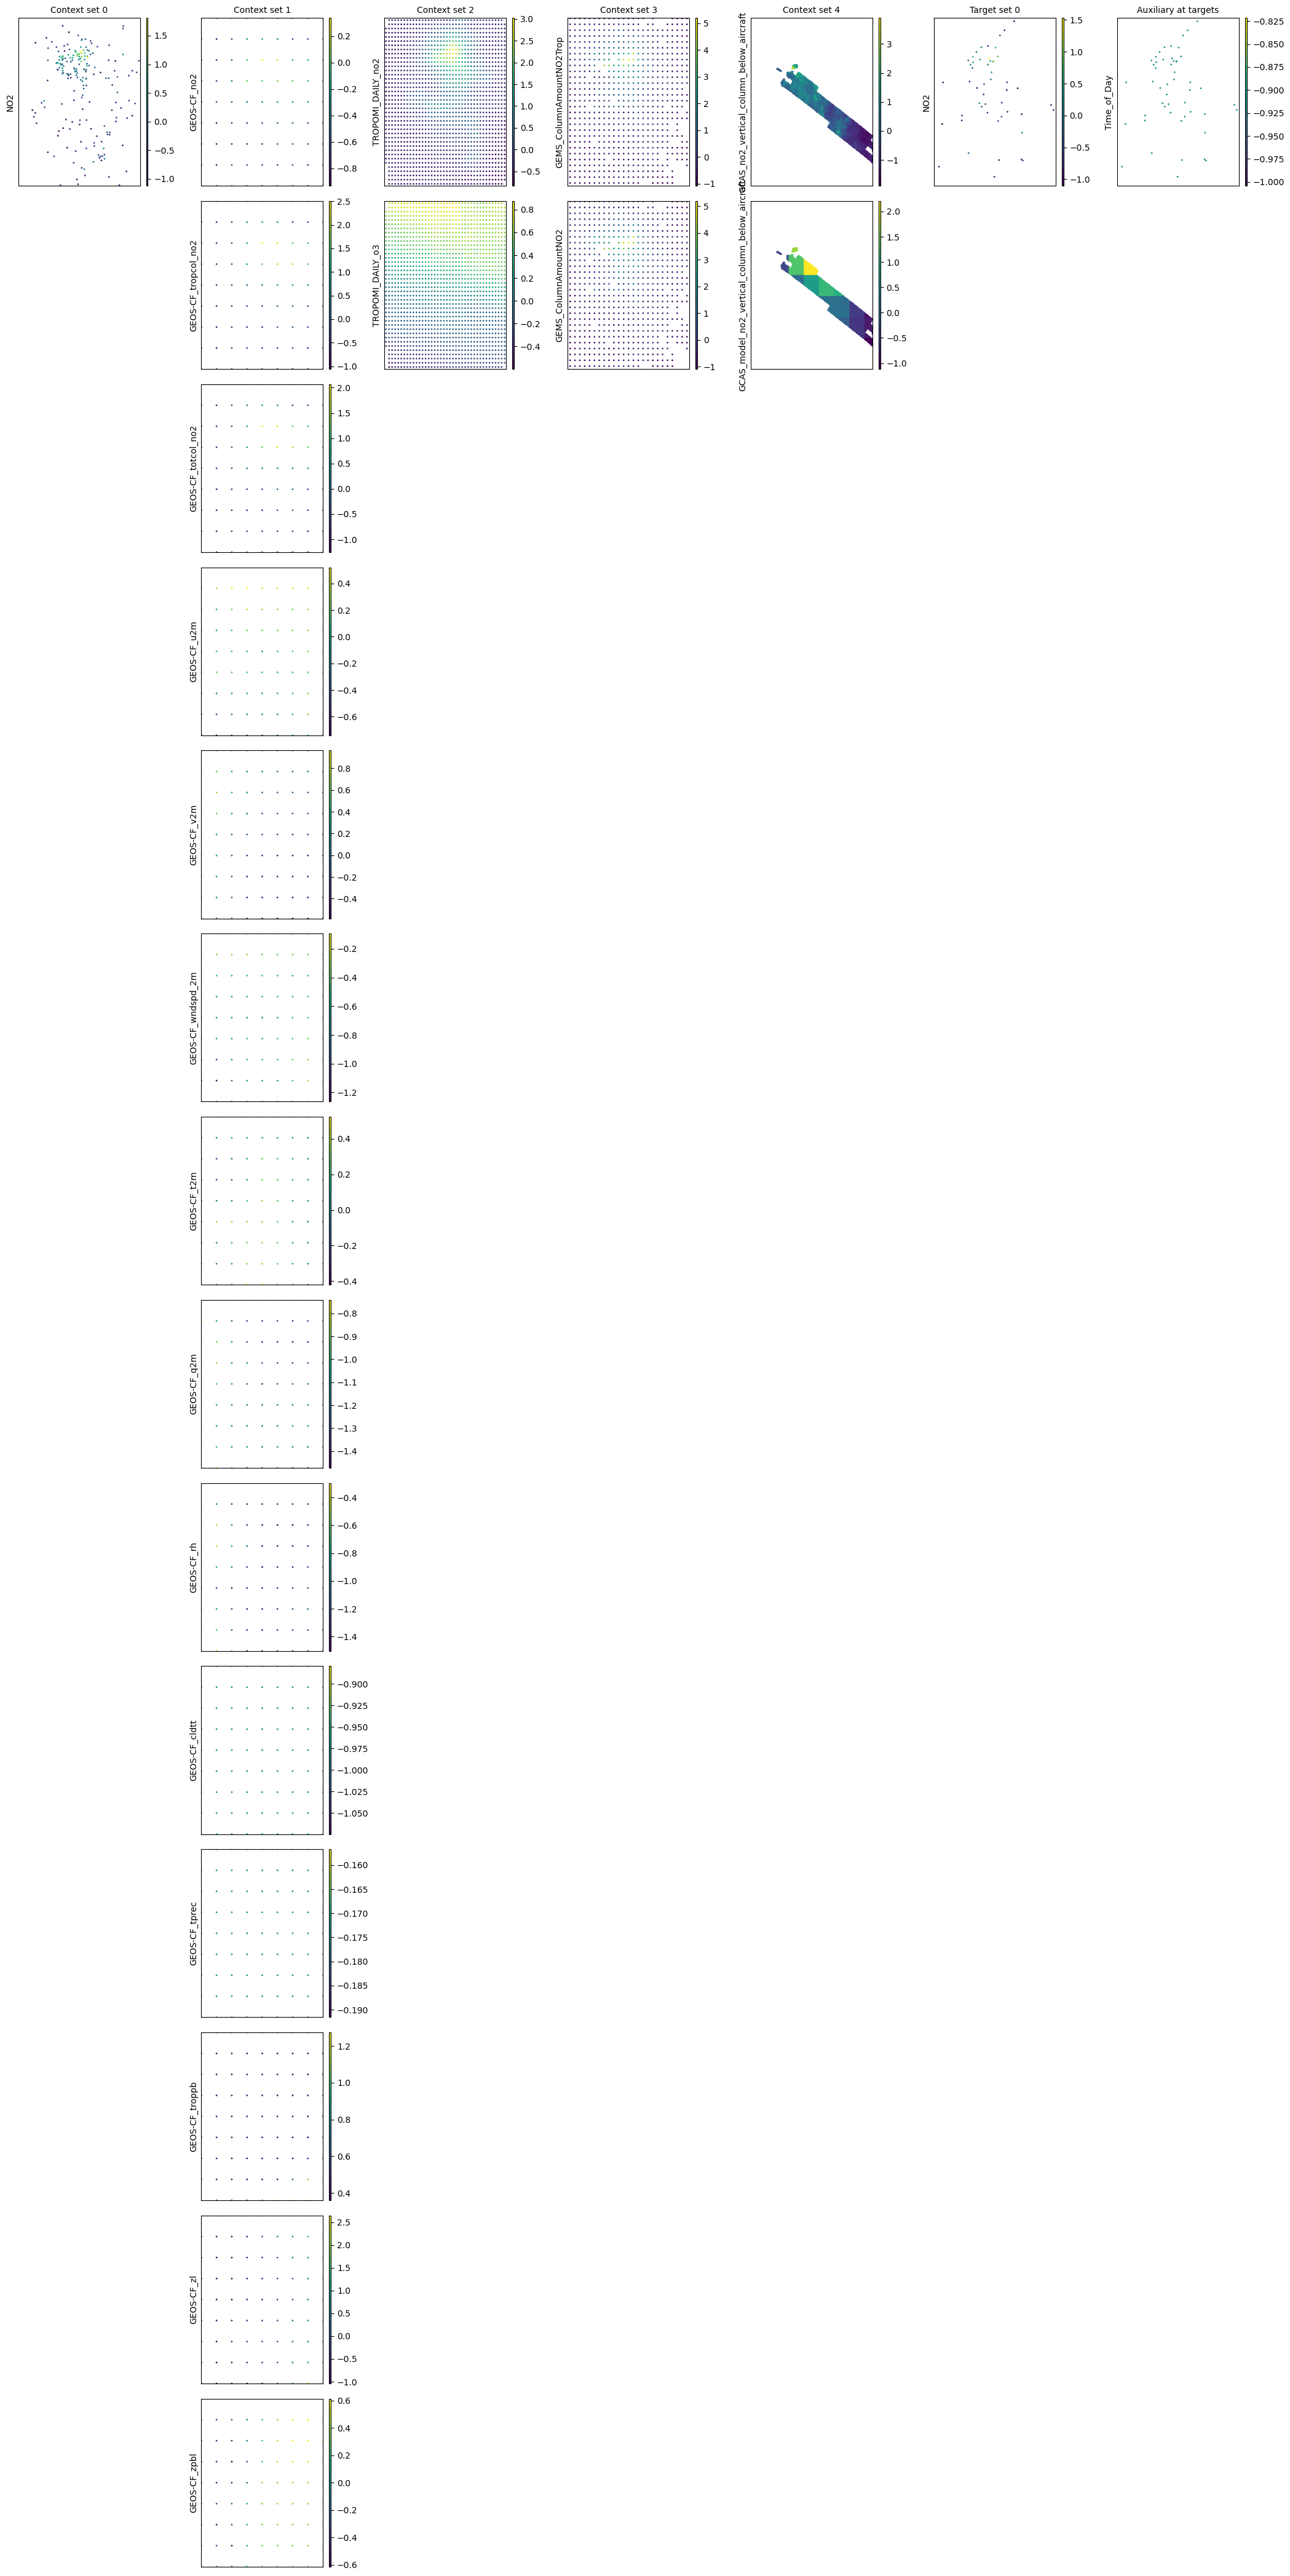

In [25]:
# Define the task loaders for training and testing datasets:
l_training_context = []
l_testing_context = []
l_train_context_sampling = []
l_test_context_sampling = []

if Consider_ground_monitors_as_input:
    Training_Links = [(0,0)]
    Training_Target_Sampling = "split"
else:
    Training_Links = None
    Training_Target_Sampling = "all"

for s_type in v_datatypes:
    if (s_type == 'airkorea'):
        if Consider_ground_monitors_as_input:
            l_training_context += [d_training_processed['airkorea']]
            l_train_context_sampling += ["split"]
    elif (s_type == 'airkorea_input'):
        if Consider_ground_monitors_as_input:
            l_testing_context = [d_testing_processed['airkorea_input']]
            l_test_context_sampling += ["all"]
    else:
        l_training_context += [d_training_processed[s_type]]
        l_train_context_sampling += ["all"]
        l_testing_context += [d_testing_processed[s_type]]
        l_test_context_sampling += ["all"]

training_task_loader = TaskLoader(
    context=l_training_context,
    # aux_at_contexts=(0,a_data_LULC_processed),
    target=d_training_processed['airkorea'],
    aux_at_targets=a_data_AUX_processed,
    links=Training_Links # This denotes to the task loader than the 0-index context input should be "linked" with the 0-index target output, i.e., they are the same thing so if you are doing a split it knows what the samples should be split between
)
testing_task_loader = TaskLoader(
    context=l_testing_context,
    # aux_at_contexts=(0,a_data_LULC_processed),
    target=d_testing_processed['airkorea'],
    aux_at_targets=a_data_AUX_processed,
)

print('Training Task Loader Information:')
print(training_task_loader)
print('\n')
# task_loader.save(processor_dir)

# Create a testing task using the task loader:
example_task = testing_task_loader('2024-02-17 01:30:00', context_sampling=l_test_context_sampling, target_sampling="all")
print('Example Testing Task Information:')
print(example_task)
print('\n')

# Visualize the testing task:
deepsensor.plot.task(example_task, testing_task_loader)
plt.show()

# Create a training task using the task loader:
example_task_training = training_task_loader('2024-03-10 01:30:00', context_sampling=l_train_context_sampling, target_sampling=Training_Target_Sampling, split_frac=Fraction_of_ground_monitors_to_train_on)
print('Example Training Task Information:')
print(example_task)
print('\n')

# Visualize the training task:
deepsensor.plot.task(example_task_training, testing_task_loader)
plt.show()

### Define a Convolutional Neural Process Model

A convolutional nerural process is the default ML model class implemented by the Deepsensor package.

[A good primer on Nerual Processes.](https://yanndubs.github.io/Neural-Process-Family/text/Intro.html) [Details about the implementation in Deepsensor.](https://alan-turing-institute.github.io/deepsensor/user-guide/convnp.html)

Here, the default model architecture is used to initialize the model for training.

dim_yc inferred from TaskLoader: (1, 14, 2, 2, 2)
dim_yt inferred from TaskLoader: 1
dim_aux_t inferred from TaskLoader: 1
Setting aux_t_mlp_layers: (64, 64, 64)
internal_density inferred from TaskLoader: 243
encoder_scales inferred from TaskLoader: [0.00205761316872428, np.float32(0.06402147), np.float32(0.012804293), np.float32(0.017926011), np.float32(0.0025608586)]
decoder_scale inferred from TaskLoader: 0.00411522633744856


Model Configuration:
ConvNP with config:
{
    "dim_x": 2,
    "dim_yc": [
        1,
        14,
        2,
        2,
        2
    ],
    "dim_yt": 1,
    "dim_aux_t": 1,
    "dim_lv": 0,
    "conv_arch": "unet",
    "unet_channels": [
        32,
        32,
        32,
        32,
        32
    ],
    "unet_resize_convs": true,
    "unet_resize_conv_interp_method": "bilinear",
    "aux_t_mlp_layers": [
        64,
        64,
        64
    ],
    "likelihood": "het",
    "unet_kernels": 5,
    "internal_density": 243,
    "encoder_scales": [
        0.0

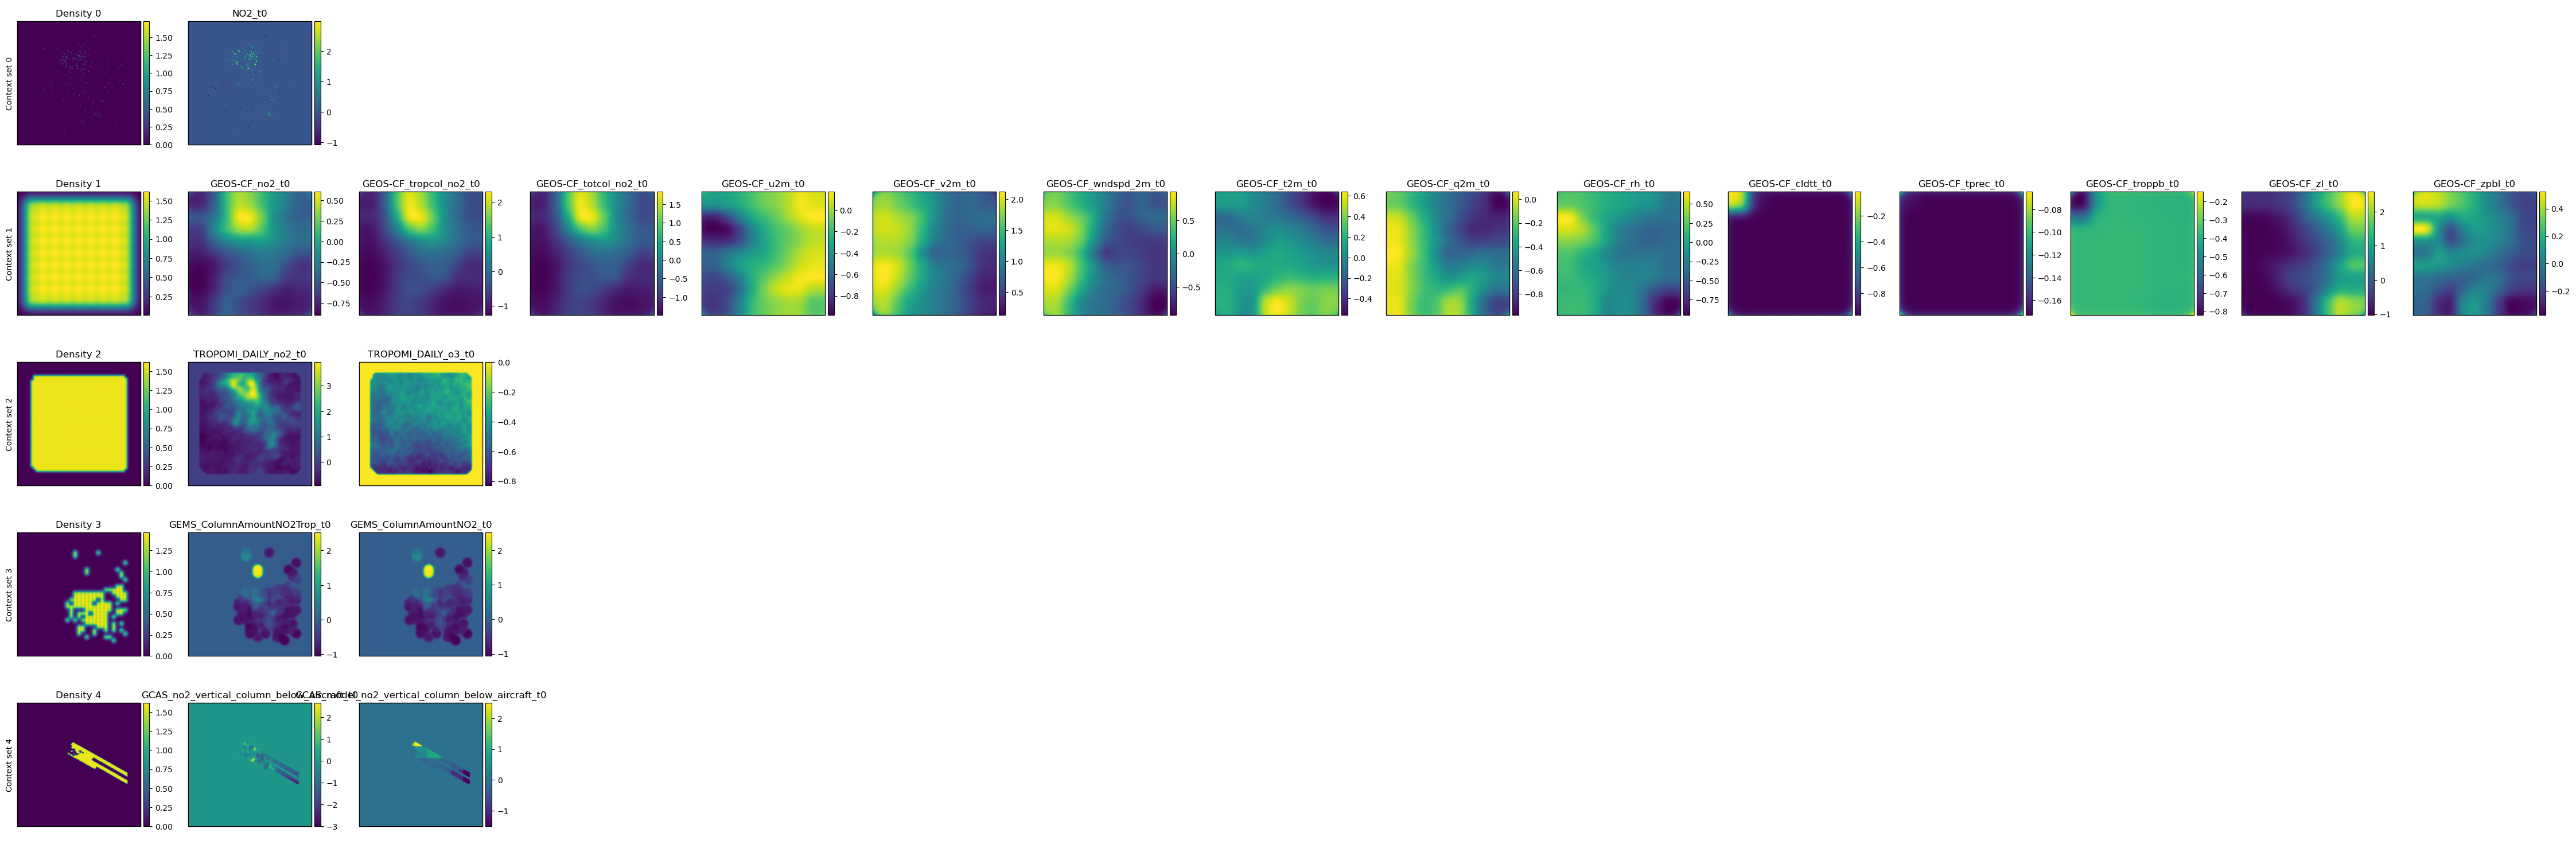

In [26]:
if b_Retrain_Model:
    model = ConvNP(data_processor, training_task_loader, unet_channels=(32, 32, 32, 32, 32))
    
    # Fix a bug: JSON is not able to encode numpy float32:
    model.config['encoder_scales'] = [float(number) for number in model.config['encoder_scales']]

    # Save the model
    model.save(processor_dir)
else:
    model = ConvNP(data_processor, training_task_loader, processor_dir)
print('\n')
print('Model Configuration:')
print(model)
print('\n')

# encode a task to tensor and visualize the encoding
task = testing_task_loader("2024-02-17 01:30:00'", "all", "all")
encoding = deepsensor.model.nps.compute_encoding_tensor(model, task)
print(f"SetConv encoding tensor shape: {encoding.shape}")
print('\n')
fig = deepsensor.plot.context_encoding(model, task, testing_task_loader)
plt.show()

# visualize the receptive field (note: will not work without internet access to download shapefiles)
# fig = deepsensor.plot.receptive_field(model.model.receptive_field, data_processor, ccrs.PlateCarree(), "seoul")
# fig.axes[0].add_feature(cfeature.BORDERS, linestyle=':')
# plt.show()

### Set Up Training & Validation Tasks and Loss Function

A Task Generator is defined, which is an application of the task loader to a list or range of timestamps (indices), used for generating sets of tasks for training and testing. Right now this is very straightforward; more options could be added inside the task generator to better control randomization for training.

A root-mean-square-error loss function is also defined to evaluate performance; my understanding is that this is not necessarily the loss function used internally for model training, but just a metric for tracking performance.


In [27]:
training_task_loader.load_dask()
testing_task_loader.load_dask()

# Define task Generators for training and testing:
def gen_training_tasks(dates, progress=True):
    tasks = []
    for date in dates:
        task = training_task_loader(date, context_sampling=l_train_context_sampling, target_sampling=Training_Target_Sampling, split_frac=Fraction_of_ground_monitors_to_train_on)
        tasks.append(task)
    return tasks

def gen_testing_tasks(dates, progress=True):
    tasks = []
    for date in dates:
        task = testing_task_loader(date, context_sampling=l_test_context_sampling, target_sampling="all")
        tasks.append(task)
    return tasks

# Generate Training and Testing Evaluation Tasks
train_tasks = gen_training_tasks(v_time_train)
test_tasks = gen_testing_tasks(v_time_test)

# Define an RMSE loss function for evalauting performance
def compute_model_rmse(model, val_tasks=test_tasks):
    errors = []
    target_var_ID = testing_task_loader.target_var_IDs[0][0]  # assume 1st target set and 1D
    for task in val_tasks:
        mean = data_processor.map_array(model.mean(task), target_var_ID, unnorm=True)
        true = data_processor.map_array(task["Y_t"][0], target_var_ID, unnorm=True)
        errors.extend(np.abs(mean - true))
    return np.sqrt(np.nanmean(np.concatenate(errors) ** 2)) # RMSE loss

if b_Retrain_Model:
    # Check number of model parameters
    _ = model(train_tasks[0])
    print(f"Model has {deepsensor.backend.nps.num_params(model.model):,} parameters")
    
    # test that the loss function computes:
    print('Loss funcion of untrained model: {}'.format(compute_model_rmse(model, val_tasks=train_tasks)))
else:
    print('Model is not going to be retrained.')


Model has 365,608 parameters
Loss funcion of untrained model: 11.154256820678711


### Training

Our training strategy will be to pass a subset of the training tasks (in this case, every seventh task) into the trainer durign each epoch, and evalaute overall performance on the entire set of training tasks. If performance is improved from one epoch to the next, the new model configuration will be saved.



In [ ]:
if b_Retrain_Model:
    losses = []
    val_rmses = []
    train_times = []
    n_max_epoch = 50
    
    val_rmse_best = np.inf
    trainer = Trainer(model, lr=5e-5)

    timer_start = time.time()
    for epoch in range(n_max_epoch):
        batch_losses = trainer(train_tasks[epoch%7:len(train_tasks):7]) # Use a subset (1/7) of the total training tasks in each epoch
        losses.append(np.mean(batch_losses))
        val_rmses.append(compute_model_rmse(model, val_tasks=train_tasks)) # evalaute model against full training dataset
        train_times.append((time.time()-timer_start)/60)
        if val_rmses[-1] < val_rmse_best:
            val_rmse_best = val_rmses[-1]
            # Fix a bug: JSON is not able to encode numpy float32:
            model.config['encoder_scales'] = [float(number) for number in model.config['encoder_scales']]
            model.save(processor_dir)
        print(f'Training epoch {epoch+1} of {n_max_epoch}; loss {val_rmse_best}; elapsed time {(time.time()-timer_start)/60} min')

    # save to CSV
    f_training_log = pd.DataFrame({'Epoch':np.arange(0,n_max_epoch),'Training Loss':losses,'Validation RMSE':val_rmses,'Training Time (minutes)':train_times})
    f_training_log.to_csv(os.path.join(processor_dir,'training_log.csv'))

else:
    print('Model was not retrained.')
    f_training_log = pd.read_csv(os.path.join(processor_dir,'training_log.csv'))
    
# visualize loss function improvement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(f_training_log['Training Loss'])
axes[1].plot(f_training_log['Validation RMSE'])
_ = axes[0].set_xlabel("Epoch")
_ = axes[1].set_xlabel("Epoch")
_ = axes[0].set_title("Training loss")
_ = axes[1].set_title("Validation RMSE")


Training epoch 1 of 50; loss 10.445120811462402; elapsed time 0.2884671092033386 min
Training epoch 2 of 50; loss 9.168050765991211; elapsed time 0.5516089995702108 min
Training epoch 3 of 50; loss 9.132135391235352; elapsed time 0.8144419391949972 min
Training epoch 4 of 50; loss 8.957015991210938; elapsed time 1.0775195995966593 min
Training epoch 5 of 50; loss 8.571901321411133; elapsed time 1.340963594118754 min
Training epoch 6 of 50; loss 8.514369010925293; elapsed time 1.6038532336552938 min
Training epoch 7 of 50; loss 8.422457695007324; elapsed time 1.867017650604248 min
Training epoch 8 of 50; loss 8.422457695007324; elapsed time 2.1303083022435505 min
Training epoch 9 of 50; loss 7.91933012008667; elapsed time 2.394135109583537 min
Training epoch 10 of 50; loss 7.903209209442139; elapsed time 2.6573845545450845 min
Training epoch 11 of 50; loss 7.903209209442139; elapsed time 2.920393494764964 min
Training epoch 12 of 50; loss 7.486603260040283; elapsed time 3.18367072741190

### Visualize Trained Model Output

To visualize the results of the trained model, we will generate a task form the testing dataset, and feed the context from this task into the trained model as input. For the target, we define a fine mesh grid (0.01-degree lat-lon spacing) over the domain, feeding this into the model as the task target.

To the left, the mean prediciton is plotted, and to the right is the estiamted standard deviation of the prediction. You can see this makes some physical sense: overall, the spatial pattern matches what we might expect for NO2 concentration distribution. There are "bumps" in the vicinity of ground monitors, especailly in the more remote areas. There is a "swath" of different concentrations (with more spatail definition) associated with the GCAS overflight. The standard deviation tends to be lower in regions with more data, although it is also proportional to the concentrations.

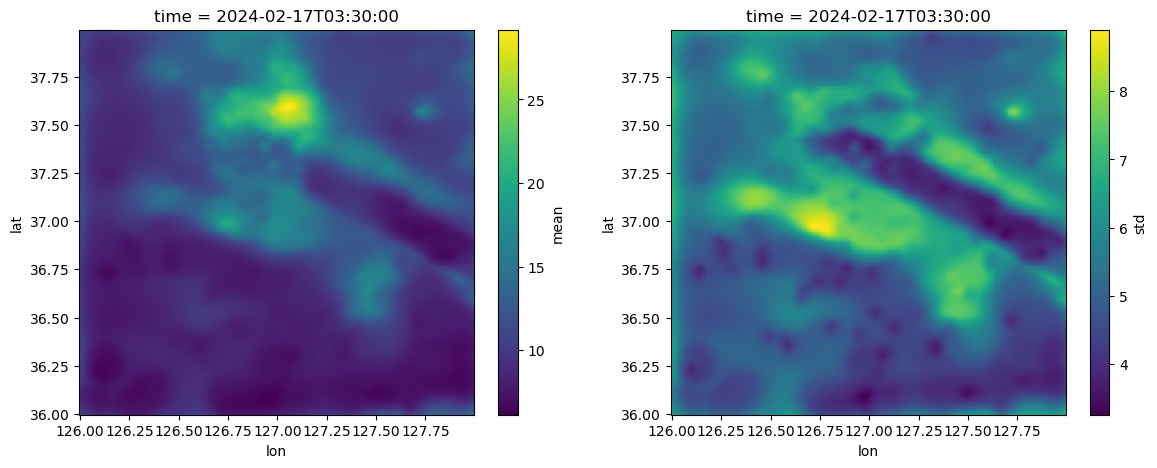

In [42]:
# Pick a result to plot
date = '2024-02-17T03:30:00' # Note: in testing set
# date = '2024-02-17T14:30:00' # Note: in testing set
# date = '2024-03-01T02:30:00' # Note: in training set
# date = '2024-03-10T01:30:00' # Note: in training set

test_task = testing_task_loader(date, context_sampling="all", target_sampling="all")

# Define a complete set of coordinates for evaluation:
X_t_all = xr.Dataset({'target':xr.DataArray(np.nan,dims=('lat','lon'),coords={'lat':np.arange(36,38,0.01),'lon':np.arange(126,128,0.01)})})

# Predict outputs:
pred = model.predict(test_task, X_t=X_t_all, resolution_factor=1)

# visualize the prediction:
# Plotting doesn't work properly since the shapefiles for the region can't be accessed on Discover.
# o_fig_out = deepsensor.plot.prediction(pred, date, data_processor, task_loader, test_task, crs=ccrs.PlateCarree())
# plt.show()

o_fig_out, o_ax_out = plt.subplots(1,2,figsize=(14, 5))
pred['NO2']['mean'].squeeze('time').plot(ax=o_ax_out[0])
pred['NO2']['std'].squeeze('time').plot(ax=o_ax_out[1])
plt.show()

Overlaying all the monitor data onto a map to better visualize

In [43]:
# helper function: plotting on a map
def F_plot_map(a_data_plot,
               a_data_plot_point=None,
               n_lat_min=-90,
               n_lat_max=90,
               n_lon_min=-180,
               n_lon_max=180,
               my_cmap = plt.get_cmap('Blues'),
               Colorbar_Label = None,
               Plot_Title = None,
               Colorbar_Limits = None,
               n_pointsize = 20,
               o_figure = None,
               o_axis = None,
               o_plot = None,
               SHOW=True):
  if o_figure is None:
      o_figure,o_axis = plt.subplots(1,1)
      o_axis.remove()
      o_axis = o_figure.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
      # mapobj = plt.figure().add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
      # mapobj = mapobj.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())

  # mapobj.coastlines();
  # mapobj.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none', linestyle='-');
  # mapobj.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  o_axis.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  gridlines = o_axis.gridlines(crs=cartopy.crs.PlateCarree(), xlocs=range(np.int_(np.floor(np.max([n_lon_min,-180]))),np.int_(np.ceil(np.min([n_lon_max,180])))+1), ylocs=range(np.int_(np.floor(np.max([n_lat_min,-90]))),np.int_(np.ceil(np.min([n_lat_max,90])))+1), draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
  gridlines.top_labels = False
  gridlines.right_labels = False
  if a_data_plot is not None:
    if 'time' in a_data_plot.dims:
      # take average for plotting:
      a_data_plot = a_data_plot.mean(dim='time')
    if Colorbar_Limits is None:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap)
    else:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1])
  if a_data_plot_point is not None:
    if type(a_data_plot_point) is pd.Series:
        f_data_plot_point = a_data_plot_point
        if 'time' in f_data_plot_point.index.names:
            f_data_plot_point = f_data_plot_point.groupby(['lat','lon']).mean('time')
        v_lat_plot = f_data_plot_point.reset_index()['lat'].values
        v_lon_plot = f_data_plot_point.reset_index()['lon'].values
        v_data_temp = f_data_plot_point.values
    else:
        v_lat_plot = np.array(a_data_plot_point.lat)
        v_lon_plot = np.array(a_data_plot_point.lon)
        if 'time' in a_data_plot_point.dims:
          # take average for plotting:
          v_data_temp = np.array(a_data_plot_point.mean(dim='time'))
        else:
          v_data_temp = np.array(a_data_plot_point)
    if Colorbar_Limits is None:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,cmap=my_cmap)
    else:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cmap=my_cmap)
    #if a_data_plot is None:
    #  if Colorbar_Label is not None:
    #    o_axis.colorbar().set_label(Colorbar_Label)
    #  else:
    #    o_axis.colorbar()
  if Plot_Title is not None:
    o_axis.set_title(Plot_Title)
  if SHOW:
    o_figure.show()
  return o_figure,o_axis,o_plot

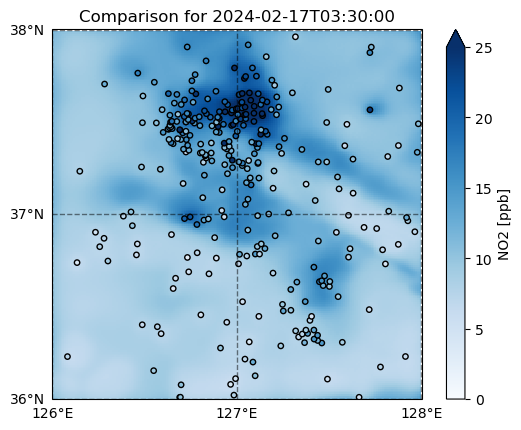

In [44]:
# plot results for comparison
o_fig,o_ax,o_plot =  F_plot_map(pred['NO2']['mean'].mean('time'),
                                a_data_plot_point = f_data_airkorea_aligned.loc[date]['NO2'],
                                n_lat_min=36,
                                n_lat_max=38,
                                n_lon_min=126,
                                n_lon_max=128,
                                my_cmap = plt.get_cmap('Blues'),
                                Colorbar_Label = 'NO2 [ppb]',
                                Plot_Title = f'Comparison for {date}',
                                # Colorbar_Limits = (0,f_data_airkorea_aligned.loc[date]['NO2'].max()),
                                Colorbar_Limits = (0,25),
                                n_pointsize=15)

## Evalaute Performance Quantitatively

In [45]:
# Baseline 1: GEOS-CF Values at Coordinates
def F_get_geoscf(a_data_geoscf,
                 time,
                 coords):
    a_geos_time = a_data_geoscf.sel(time=time)['GEOS-CF_no2']*1e9
    v_out = []
    for i_ndex in range(len(coords[0])):
        v_out += [a_geos_time.interp({'lat':coords[0][i_ndex],'lon':coords[1][i_ndex]}).values]
    return np.array(v_out)

# Baseline 2: Nearest Ground Monitor
def F_get_nearest(coords,true):
    v_out = []
    for i_ndex in range(len(coords[0])):
        sq_dist = ((coords[0] - coords[0][i_ndex])**2) + ((coords[1] - coords[1][i_ndex])**2)
        sq_dist[i_ndex] = np.nan
        id_nearest = np.nanargmin(sq_dist)
        v_out += [true[id_nearest]]
    return np.array(v_out)
def F_get_nearest_from_input(coords,coords_input,true_input):
    v_out = []
    for i_ndex in range(len(coords[0])):
        sq_dist = ((coords_input[0] - coords[0][i_ndex])**2) + ((coords_input[1] - coords[1][i_ndex])**2)
        id_nearest = np.nanargmin(sq_dist)
        v_out += [true_input[id_nearest]]
    return np.array(v_out)
    

# Apply model to validation tasks:
if b_Repeat_Evaluation:
    l_errors = []
    for val_task in test_tasks:
        time = val_task['time']
        target_var_ID = testing_task_loader.target_var_IDs[0][0]
        # mean = data_processor.map_array(model.mean(val_task), target_var_ID, unnorm=True)
        true = data_processor.map_array(val_task['Y_t'][0], target_var_ID, unnorm=True)[0]
        coords = data_processor.map_coord_array(val_task['X_t'][0], unnorm=True)
        pred = model.predict(val_task, X_t = coords)
        mean = pred[target_var_ID]['mean'].values
        std = pred[target_var_ID]['std'].values
        geos = F_get_geoscf(a_data_GEOSCF_aligned,time,coords)
        if Consider_ground_monitors_as_input:
            coords_input = data_processor.map_coord_array(val_task['X_c'][0], unnorm=True)
            true_input = data_processor.map_array(val_task['Y_c'][0], 'NO2', unnorm=True)[0]
            near = F_get_nearest_from_input(coords,coords_input,true_input)
        else:
            near = F_get_nearest(coords,true)
        
        f_errors_task = pd.DataFrame({'time':np.array([time]*len(true)),
                                     'lat':coords[0],
                                     'lon':coords[1],
                                     'Truth':true,
                                     'Model':mean - true,
                                     'Model_Normalized':((mean - true)/std), 
                                     'Baseline_GEOSCF':geos - true,
                                     'Baseline_Nearest':near - true,
                                     })
        l_errors += [f_errors_task]
        print(f'Evalaution complete for {time}')
    
    f_errors = pd.concat(l_errors)

    # Save:
    f_errors.to_csv(os.path.join(processor_dir,'evaluation_errors.csv'),index=False)
else:
    # Load:
    f_errors = pd.read_csv(os.path.join(processor_dir,'evaluation_errors.csv'))
    # Ensure time is timestamps
    f_errors['time'] = pd.to_datetime(f_errors['time'])
 
    print('Saved evaluation results loaded.')
f_errors = f_errors.set_index(['time','lat','lon'])
f_errors


Evalaution complete for 2024-02-01 00:30:00
Evalaution complete for 2024-02-01 01:30:00
Evalaution complete for 2024-02-01 02:30:00
Evalaution complete for 2024-02-01 03:30:00
Evalaution complete for 2024-02-01 04:30:00
Evalaution complete for 2024-02-01 05:30:00
Evalaution complete for 2024-02-01 06:30:00
Evalaution complete for 2024-02-01 07:30:00
Evalaution complete for 2024-02-01 08:30:00
Evalaution complete for 2024-02-01 09:30:00
Evalaution complete for 2024-02-01 10:30:00
Evalaution complete for 2024-02-01 11:30:00
Evalaution complete for 2024-02-01 12:30:00
Evalaution complete for 2024-02-01 13:30:00
Evalaution complete for 2024-02-01 14:30:00
Evalaution complete for 2024-02-01 15:30:00
Evalaution complete for 2024-02-01 16:30:00
Evalaution complete for 2024-02-01 17:30:00
Evalaution complete for 2024-02-01 18:30:00
Evalaution complete for 2024-02-01 19:30:00
Evalaution complete for 2024-02-01 20:30:00
Evalaution complete for 2024-02-01 21:30:00
Evalaution complete for 2024-02-

Truth     Model  \
time                lat       lon                               
2024-02-01 00:30:00 36.007999 126.690300  15.100000 -6.519588   
                    36.076172 126.697914  10.200000 -2.468964   
                    36.152878 126.549347  11.400000 -4.380076   
                    36.229500 127.913200  21.900000 -7.693475   
                    36.306381 127.571236  27.299999 -7.094242   
...                                             ...       ...   
2024-02-29 23:30:00 37.831219 127.509773   4.000000  8.723804   
                    37.917599 127.061295   5.700000  5.913575   
                    37.404659 126.696915   5.900000   2.54572   
                    36.632492 127.325127   7.600000  0.252039   
                    36.922699 127.757401   7.700000  1.269656   

                                         Model_Normalized  Baseline_GEOSCF  \
time                lat       lon                                            
2024-02-01 00:30:00 36.007999 126.690300        -1.366489        -7.116330   
                    36.076172 126.697914         -0.57361        -2.135603   
                    36.152878 126.549347        -1.061605        -4.646321   
                    36.229500 127.913200        -1.155343        -5.835067   
                    36.306381 127.571236        -0.784628       -11.740514   
...                                                   ...              ...   
2024-02-29 23:30:00 37.831219 127.509773         1.226564        -2.269123   
                    37.917599 127.061295         0.887431        -3.226215   
                    37.404659 126.696915         0.509817        -1.105501   
                    36.632492 127.325127         0.054829        -3.396416   
                    36.922699 127.757401         0.259154        -2.457717   

                                          Baseline_Nearest  
time                lat       lon                           
2024-02-01 00:30:00 36.007999 126.690300         -5.700001  
                    36.076172 126.697914         -0.800000  
                    36.152878 126.549347         -2.000000  
                    36.229500 127.913200         14.100000  
                    36.306381 127.571236          4.300001  
...                                                    ...  
2024-02-29 23:30:00 37.831219 127.509773          1.800000  
                    37.917599 127.061295         -1.500000  
                    37.404659 126.696915          1.300000  
                    36.632492 127.325127          0.099999  
                    36.922699 127.757401         -2.099999  

[42829 rows x 5 columns]

### Helper Function to Calculate Metrics

In [46]:
def F_evaluate_metrics(f_errors_in,l_to_evaluate = ['Model','Baseline_GEOSCF','Baseline_Nearest'],v_special_times_to_evaluate=None):
    if v_special_times_to_evaluate is not None:
        l_desired_times = [str(desired_time)[0:19].replace('T',' ') for desired_time in v_special_times_to_evaluate]
        f_errors = f_errors_in.loc[l_desired_times]
    else:
        f_errors = f_errors_in
    
    bias = f_errors[l_to_evaluate].mean()
    mae = abs(f_errors[l_to_evaluate]).mean()
    ms_res = ((f_errors[l_to_evaluate])**2).mean()
    rmse = ms_res**0.5
    ms_tot = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).mean()
    r2_all = 1-(ms_res/ms_tot)
    # !!! There is some issue with the correlation calculation, observed when running on GPU !!!
    try:
        r_all = np.corrcoef(np.concatenate([np.array([f_errors['Truth']]).transpose(),
                                            np.repeat(np.array([f_errors['Truth']]), len(l_to_evaluate), axis=0).transpose() + np.array(f_errors[l_to_evaluate])
                                           ],axis=1).transpose())[0,1:len(l_to_evaluate)+1]
    except:
        r_all = []
        for s_col in l_to_evaluate:
            v_y = f_errors['Truth'] - f_errors['Truth'].mean()
            v_x = (f_errors[s_col] + f_errors['Truth']) - (f_errors[s_col] + f_errors['Truth']).mean()
            n_r = ((v_x * v_y).sum())/((((v_x**2).sum())**0.5)*(((v_y**2).sum())**0.5))
            r_all += [n_r]
        
    ms_res_time = ((f_errors[l_to_evaluate])**2).groupby(['lat','lon']).mean()
    ms_tot_time = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).groupby(['lat','lon']).mean()
    r2_all_time = ms_res_time.join(ms_tot_time)
    for s_to_evalaute in l_to_evaluate:
        r2_all_time[s_to_evalaute] = 1-(r2_all_time[s_to_evalaute]/r2_all_time['Truth'])
    r2_med_time = r2_all_time[l_to_evaluate].median()
    r2_avg_time = r2_all_time[l_to_evaluate].mean()
    
    ms_res_space = ((f_errors[l_to_evaluate])**2).groupby(['time']).mean()
    ms_tot_space = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).groupby(['time']).mean()
    r2_all_space = ms_res_space.join(ms_tot_space)
    for s_to_evalaute in l_to_evaluate:
        r2_all_space[s_to_evalaute] = 1-(r2_all_space[s_to_evalaute]/r2_all_space['Truth'])
    r2_med_space = r2_all_space[l_to_evaluate].median()
    r2_avg_space = r2_all_space[l_to_evaluate].mean()

    f_metrics = pd.DataFrame({'Bias':bias,
                              'MAE':mae,
                              'RMSE':rmse,
                              'r (all)':r_all,
                              'R^2 (all)':r2_all,
                              'R^2 (space, median)':r2_med_space,
                              'R^2 (time, median)':r2_med_time,
                             })
    
    return f_metrics

### Evaluate Overall Performance

In [47]:
# Evaluate Performance Metrics    
f_metrics = F_evaluate_metrics(f_errors)

# Display Metrics
print('Overall Performance:')
f_metrics

Overall Performance:


,Bias,MAE,RMSE,r (all),R^2 (all),"R^2 (space, median)","R^2 (time, median)"
Model,1.169601,5.742963,7.766923,None,0.624288,0.59577,0.698739
Baseline_GEOSCF,-1.180342,9.350729,12.211264,None,0.071294,0.141529,0.053333
Baseline_Nearest,0.406475,5.702045,8.078266,None,0.593563,0.569566,0.633231


### Hourly Performance by Time of Day

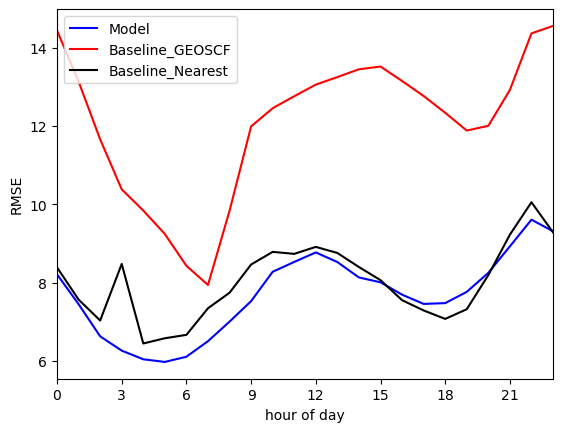

In [48]:
# Evaluate time-of-day performance
v_hour = pd.to_datetime(f_errors.reset_index()['time']).dt.hour
v_hour.index = f_errors.index

n_UTC_offset = 9

d_hourly_metrics = {}
for i_hour in range(0,24):
    i_hour_utc = (i_hour - n_UTC_offset) % 24
    d_hourly_metrics[i_hour] = F_evaluate_metrics(f_errors[v_hour == i_hour_utc])

s_metric_to_plot = 'RMSE'

plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Model'] for i_hour in range(0,24)],label='Model',color='blue')
plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Baseline_GEOSCF'] for i_hour in range(0,24)],label='Baseline_GEOSCF',color='red')
plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Baseline_Nearest'] for i_hour in range(0,24)],label='Baseline_Nearest',color='black')
plt.xlabel('hour of day [local time]')
plt.xlim([0,23])
plt.xticks(np.arange(0,24,3))
plt.ylabel(s_metric_to_plot)
plt.legend()

### Evaluate Normality of Residuals to test uncertainty estimation

Mean: 0.07542129104115863 [Ideal: 0]
Standard Deviation: 1.0194771167035772 [Ideal: 1]
Skewness: -1.161545991897583 [Ideal: 0]
Kurtosis: 3.164891242980957 [Ideal: 0]


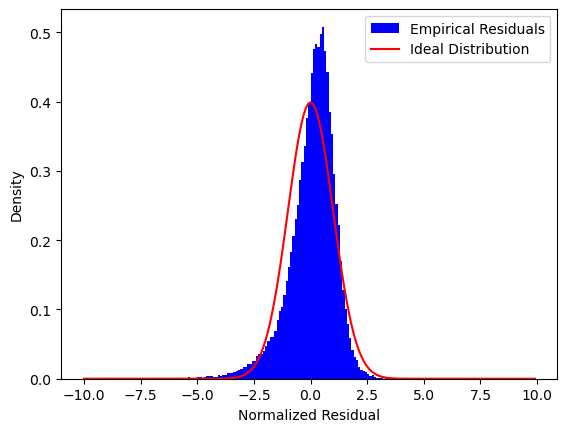

In [49]:
v_bins = np.arange(-10,10,0.1)
v_residuals = f_errors['Model_Normalized'].values

# Compute Mean, SD, Skewness, Kurtosis
print(f'Mean: {v_residuals.mean()} [Ideal: 0]')
print(f'Standard Deviation: {v_residuals.std()} [Ideal: 1]')
print(f'Skewness: {sps.skew(v_residuals.astype('f'))} [Ideal: 0]')
print(f'Kurtosis: {sps.kurtosis(v_residuals.astype('f'))} [Ideal: 0]')

# plot histogram of residuals
plt.hist(v_residuals,bins=v_bins,color='blue',label='Empirical Residuals',density=True)
# plot normal distrubution

plt.plot(v_bins,sps.norm.pdf(v_bins),color='red',label='Ideal Distribution')

# Fit a Lognormal Distribution to the data:
# fitted_lognormal = sps.lognorm.fit(np.array([n_residual for n_residual in v_residuals if not np.isnan(n_residual)]))
# plt.plot(v_bins,sps.lognorm.pdf(v_bins,fitted_lognormal[0],fitted_lognormal[1],fitted_lognormal[2]),color='orange',label='Fitted Lognormal Distribution')

plt.xlabel('Normalized Residual')
plt.ylabel('Density')
plt.legend()



### Performance at times with and without specific data

In [23]:
s_dataset_to_test = 'GCAS'
s_variable_to_test = 'GCAS_no2_vertical_column_below_aircraft'
# s_dataset_to_test = 'GEMS'
# s_variable_to_test = 'GEMS_ColumnAmountNO2Trop'
v_hours_with_data = d_testing[s_dataset_to_test].time.where(((~np.isnan(d_testing[s_dataset_to_test][s_variable_to_test])).any(dim=('lat','lon')))).dropna('time')
v_hours_without_data = [hour for hour in v_time_test if not hour in v_hours_with_data]

f_metrics_with_data = F_evaluate_metrics(F_align_times(f_errors,v_hours_with_data))
f_metrics_with_data[s_dataset_to_test] = True
f_metrics_with_data = f_metrics_with_data.set_index(s_dataset_to_test, append=True)

f_metrics_without_data = F_evaluate_metrics(F_align_times(f_errors,v_hours_without_data))
f_metrics_without_data[s_dataset_to_test] = False
f_metrics_without_data = f_metrics_without_data.set_index(s_dataset_to_test, append=True)

# Display Metrics
print(f'Performance with or without {s_dataset_to_test}:')
f_metrics = pd.concat([f_metrics_with_data,f_metrics_without_data])#.reorder_levels(['GCAS',None])
f_metrics.sort_index(ascending=False,sort_remaining=False)



Performance with or without GCAS:


Bias       MAE       RMSE   r (all)  R^2 (all)  \
                 GCAS                                                        
Model            True   1.156208  4.610970   6.124315  0.804230   0.633674   
                 False  1.482884  5.718936   7.520281  0.817631   0.650702   
Baseline_Nearest True   0.404542  4.829345   6.874770  0.766854   0.538397   
                 False  0.406528  5.726017   8.108804  0.799500   0.593892   
Baseline_GEOSCF  True  -7.582496  8.426356  11.183177  0.583557  -0.221470   
                 False -1.004484  9.376121  12.238285  0.463585   0.074943   

                        R^2 (space, median)  R^2 (time, median)  
                 GCAS                                            
Model            True              0.588746            0.708788  
                 False             0.613221            0.668365  
Baseline_Nearest True              0.432850            0.743368  
                 False             0.570849            0.630278  
Baseline_GEOSCF  True             -0.117181           -0.135047  
                 False             0.143508            0.053229

## Testing only supplying partial context:

Context Included: airkorea_input, GCAS


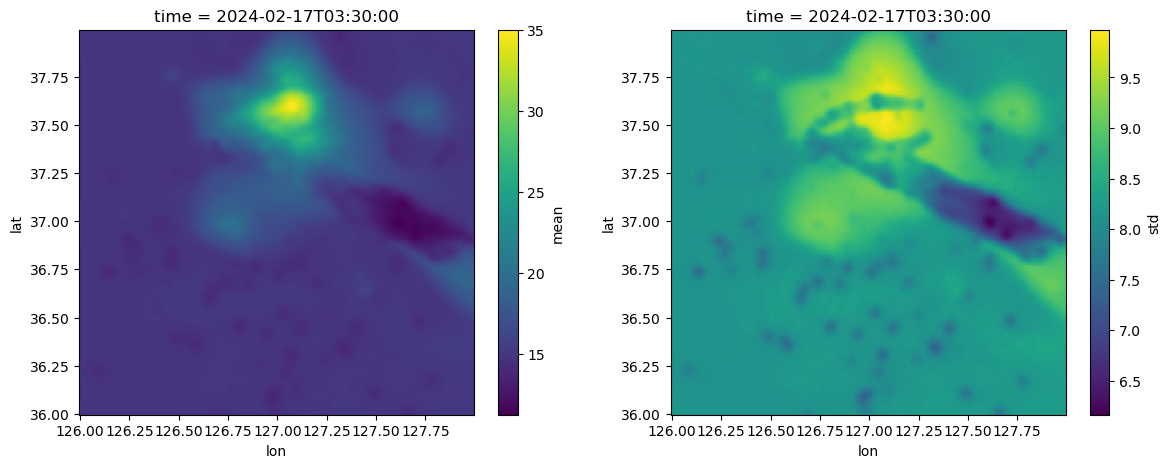

In [56]:
d_context_to_include = {'airkorea_input':True,
                       'GCAS':True,
                       'GEMS':False,
                       'TROPOMI':False,
                       'GEOSCF':False}

d_default_context = {'airkorea_input':d_testing_processed['airkorea_input'],
                       'GCAS':d_testing_processed['GCAS'],
                       'GEMS':d_testing_processed['GEMS'],
                       'TROPOMI':d_testing_processed['TROPOMI'],
                       'GEOSCF':d_testing_processed['GEOSCF']
                       #'GEOSCF':xr.merge([d_testing_processed['GEOSCF'],xr.DataArray(pd.to_datetime(v_time_test).hour,dims=('time'),coords={'time':v_time_test},name='time_of_day')])
                    }

l_context = []
for s_context in d_default_context.keys():
    if d_context_to_include[s_context]:
        l_context += [d_default_context[s_context]]
    else:
        if s_context is 'airkorea_input':
            l_context += [d_default_context[s_context].iloc[:0,:].copy()]
        else:
            l_context += [xr.full_like(d_default_context[s_context],np.nan)]

testing_task_loader_missing_context = TaskLoader(
        context=l_context,
        target=d_testing_processed['airkorea'],
        aux_at_targets=a_data_AUX_processed
        )

date = '2024-02-17T03:30:00' # Note: in testing set

test_task = testing_task_loader_missing_context(date, context_sampling="all", target_sampling="all")

# Define a complete set of coordinates for evaluation:
X_t_all = xr.Dataset({'target':xr.DataArray(np.nan,dims=('lat','lon'),coords={'lat':np.arange(36,38,0.01),'lon':np.arange(126,128,0.01)})})

# Predict outputs:
pred = model.predict(test_task, X_t=X_t_all, resolution_factor=1)

# visualize the prediction:
# Plotting doesn't work properly since the shapefiles for the region can't be accessed on Discover.
# o_fig_out = deepsensor.plot.prediction(pred, date, data_processor, task_loader, test_task, crs=ccrs.PlateCarree())
# plt.show()

l_context_included = [s_context for s_context in d_context_to_include.keys() if d_context_to_include[s_context]]
if len(l_context_included) > 0:
    s_context_included = ', '.join(l_context_included)
else:
    s_context_included= 'None'
print(f'Context Included: {s_context_included}')
o_fig_out, o_ax_out = plt.subplots(1,2,figsize=(14, 5))
pred['NO2']['mean'].squeeze('time').plot(ax=o_ax_out[0])
pred['NO2']['std'].squeeze('time').plot(ax=o_ax_out[1])
plt.show()

# Next Steps to be worked on
 - ~~Randomization of training data across epochs~~
 - ~~Quantitative evaluation of performance~~
   - ~~compare to nearest ground station~~
   - ~~compare to GEOS-CF~~
   - ~~Time-of-day performance~~
   - ~~Data-availability-based performance~~
   - ~~Compute Normalized Errors~~
 - Augment training data
   - rotations
 - Add additional context information
   - Higher resolution emissions
   - Population
   - ~~Land use/cover~~
   - ~~time-of-day indicators -> Include as part of target additional context~~
 - Test when inputs (e.g., GCAS) are missing: look at nighttime predictions
   - ~~What if you feed in an input without full context?~~
   - ~~Try a generic blank context?~~
   - Quantitative evaluations for turning on and off inputs
   - Compare to model trained without inputs
 - ~~Include some ground stations as inputs; set-up appropriate cross-validation~~
 - Evaluate importance of different input types
 - ~~Work on importing context data at original resolutions to avoid need for regridding?~~
   - ~~This would allow much easier predictions at other times since there wouldn't need to be a high-res gridded dataset of everything to pull from~~
 - ~~Time training~~
   - ~~Test CPU v. GPU (15 min GPU)~~

## Extra Materials

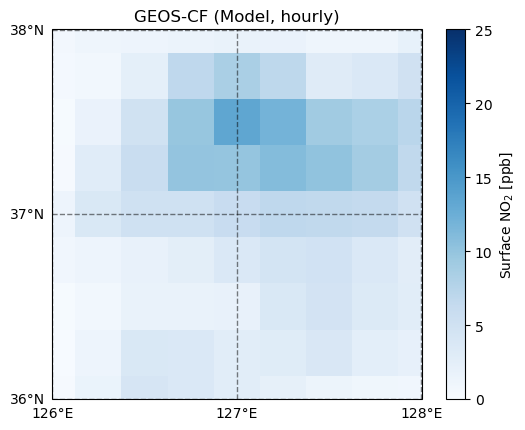

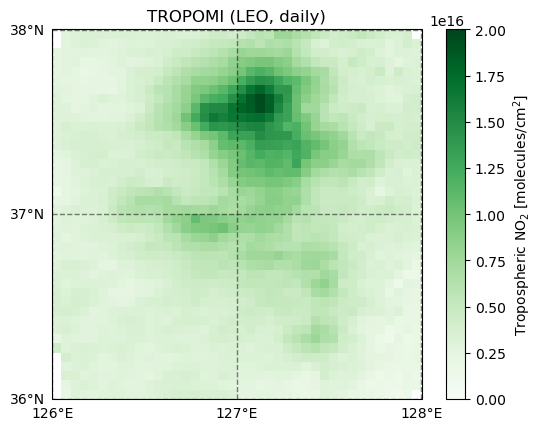

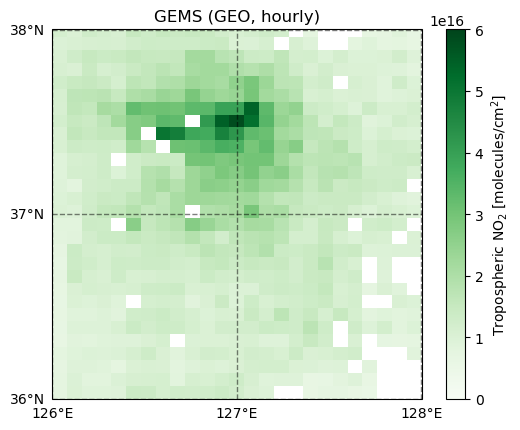

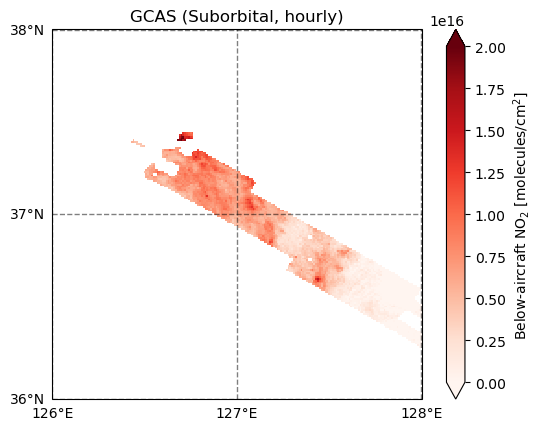

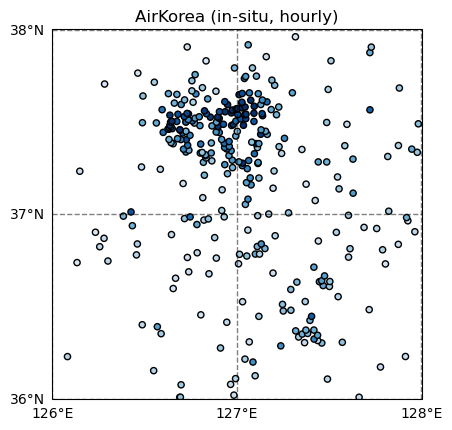

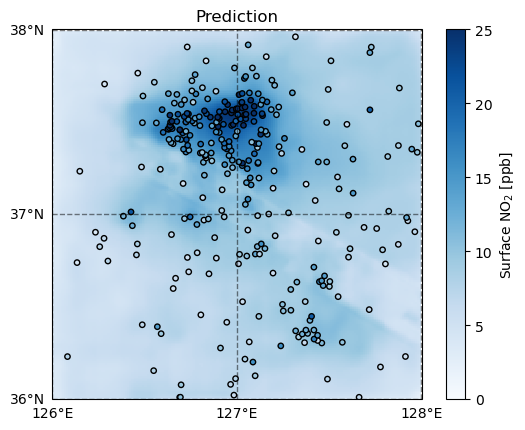

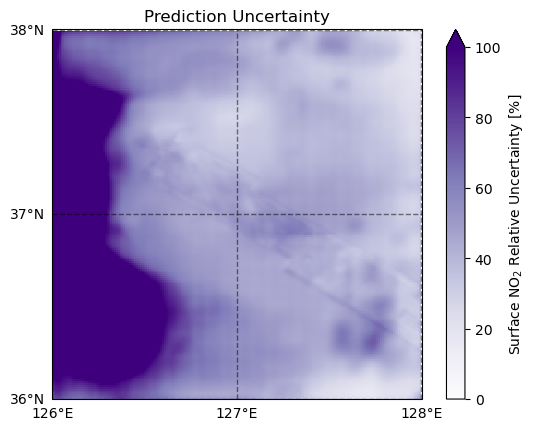

In [77]:
## Plotting example figures

date = '2024-03-10T01:30:00' # Note: in validation set

# GEOS-CF Input
o_fig,o_ax,o_plot =  F_plot_map(1e9*a_data_GEOSCF_aligned['GEOS-CF_no2'].sel(time=date),
                                    a_data_plot_point = None,
                                    n_lat_min=36,
                                    n_lat_max=38,
                                    n_lon_min=126,
                                    n_lon_max=128,
                                    my_cmap = plt.get_cmap('Blues'),
                                    Colorbar_Label = 'Surface NO$_2$ [ppb]',
                                    Plot_Title = 'GEOS-CF (Model, hourly)',
                                    Colorbar_Limits = (0,25),
                                    n_pointsize=15)

# TROPOMI Input
o_fig,o_ax,o_plot =  F_plot_map((6.022e23*((1/100)*(1/100)))*a_data_TROPOMI_daily_aligned['TROPOMI_DAILY_no2'].sel(time=date),
                                    a_data_plot_point = None,
                                    n_lat_min=36,
                                    n_lat_max=38,
                                    n_lon_min=126,
                                    n_lon_max=128,
                                    my_cmap = plt.get_cmap('Greens'),
                                    Colorbar_Label = 'Tropospheric NO$_2$ [molecules/cm$^2$]',
                                    Plot_Title = 'TROPOMI (LEO, daily)',
                                    Colorbar_Limits = (0,2e16),
                                    n_pointsize=15)


# (1e15*(1/6.022e23)*(100*100))


# GEMS Input
o_fig,o_ax,o_plot =  F_plot_map((6.022e23*((1/100)*(1/100)))*a_data_GEMS_aligned['GEMS_ColumnAmountNO2Trop'].sel(time=date),
                                    a_data_plot_point = None,
                                    n_lat_min=36,
                                    n_lat_max=38,
                                    n_lon_min=126,
                                    n_lon_max=128,
                                    my_cmap = plt.get_cmap('Greens'),
                                    Colorbar_Label = 'Tropospheric NO$_2$ [molecules/cm$^2$]',
                                    Plot_Title = 'GEMS (GEO, hourly)',
                                    Colorbar_Limits = (0,6e16),
                                    n_pointsize=15)

# GCAS input
o_fig,o_ax,o_plot =  F_plot_map(a_data_GCAS_aligned['GCAS_no2_vertical_column_below_aircraft'].sel(time=date),
                                    a_data_plot_point = None,
                                    n_lat_min=36,
                                    n_lat_max=38,
                                    n_lon_min=126,
                                    n_lon_max=128,
                                    my_cmap = plt.get_cmap('Reds'),
                                    Colorbar_Label = 'Below-aircraft NO$_2$ [molecules/cm$^2$]',
                                    Plot_Title = 'GCAS (Suborbital, hourly)',
                                    Colorbar_Limits = (0,2e16),
                                    n_pointsize=15)

# Ground Data
o_fig,o_ax,o_plot =  F_plot_map(None,
                                    a_data_plot_point = f_data_airkorea_aligned.loc[date]['NO2'],
                                    n_lat_min=36,
                                    n_lat_max=38,
                                    n_lon_min=126,
                                    n_lon_max=128,
                                    my_cmap = plt.get_cmap('Blues'),
                                    Colorbar_Label = 'Surface NO$_2$ [ppb]',
                                    Plot_Title = 'AirKorea (in-situ, hourly)',
                                    Colorbar_Limits = (0,25),
                                    n_pointsize=20)

# Prediction

test_task = task_loader(date, context_sampling=["all", "all", "all", "all"], target_sampling="all")
X_t_all = xr.Dataset({'target':xr.DataArray(np.nan,dims=('lat','lon'),coords={'lat':np.arange(36,38,0.01),'lon':np.arange(126,128,0.01)})})
pred = model.predict(test_task, X_t=X_t_all, resolution_factor=1)

o_fig,o_ax,o_plot =  F_plot_map(pred['NO2']['mean'].squeeze('time'),
                                a_data_plot_point = f_data_airkorea_aligned.loc[date]['NO2'],
                                n_lat_min=36,
                                n_lat_max=38,
                                n_lon_min=126,
                                n_lon_max=128,
                                my_cmap = plt.get_cmap('Blues'),
                                Colorbar_Label = 'Surface NO$_2$ [ppb]',
                                Plot_Title = 'Prediction',
                                Colorbar_Limits = (0,25),
                                n_pointsize=15)


# Variance
o_fig,o_ax,o_plot =  F_plot_map(100*pred['NO2']['std'].squeeze('time')/pred['NO2']['mean'].squeeze('time'),
                                a_data_plot_point = None,
                                n_lat_min=36,
                                n_lat_max=38,
                                n_lon_min=126,
                                n_lon_max=128,
                                my_cmap = plt.get_cmap('Purples'),
                                Colorbar_Label = 'Surface NO$_2$ Relative Uncertainty [%]',
                                Plot_Title = 'Prediction Uncertainty',
                                Colorbar_Limits = (0,100),
                                n_pointsize=15)
